# Pretrained → Finetune notebook scaffold

Scaffold for the pretrained→finetune experiments: baseline pretraining on movies released up to 2004, zero-shot eval on yearly buckets 2005–2019, and finetune variants. No training runs are executed yet; this notebook only sets up sections, configs, and helper stubs so we can plug in runs later.

## Hypotheses
- Full finetune delivers the best final performance but uses the most data/parameters.
- Head-only finetuning underfits and saturates early.
- LoRA/DoRA approach full finetune performance with far fewer trainable parameters.
- DoRA often adapts faster or more stably than LoRA under low-data settings.


## Outline
- Intro & goals
- Imports & config
- Data split logic (<=2004 pretrain, 2005–2019 eval buckets, post-2005 aggregate)
- Training/Eval helpers (features, loaders, metrics, checkpoints)
- Pretraining run stub
- Zero-shot eval stub
- Finetune variant stubs (full, head-only, gradual unfreeze, adapters/LoRA placeholder)
- Post-FT eval stub
- Results aggregation stub
- Plotting stub
- Reporting/notes

In [27]:
from pathlib import Path
from dataclasses import dataclass, asdict, field
from typing import Callable, Dict, List, Tuple

import json
import hashlib
import sys
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
ARTIFACT_ROOT = NOTEBOOK_DIR / "artifacts" / "pretrained_finetune"

from src.data.constants import CAT_COLS, LOG_COLS, NUMERIC_COLS, TARGET_COL
from src.data.load_data import filter_and_group, load_raw, train_val_test_split
from src.data.encode_features import (
    apply_frequency_encoders,
    apply_log1p,
    apply_rare_grouping,
    apply_scaler,
    fill_unknown_categories,
    prepare_features,
)
from src.models.model import TabularRegressor
from src.models.train import TrainConfig, make_loaders, train_model
from src.utils.checkpoints import save_checkpoint, load_checkpoint
from src.utils.plotting import boxplot_by_group


@dataclass
class NotebookPaths:
    root: Path = ARTIFACT_ROOT
    checkpoints: Path = field(init=False)
    results: Path = field(init=False)
    plots: Path = field(init=False)

    def __post_init__(self):
        self.root.mkdir(parents=True, exist_ok=True)
        self.checkpoints = self.root / "checkpoints"
        self.results = self.root / "results"
        self.plots = self.root / "plots"
        for path in (self.checkpoints, self.results, self.plots):
            path.mkdir(parents=True, exist_ok=True)


@dataclass
class ExperimentConfig:
    seed: int = 42
    seeds: List[int] = field(default_factory=lambda: [0])
    train_end_year: int = 2005
    eval_years: List[int] = field(default_factory=lambda: list(range(2005, 2020)))
    batch_size: int = 64
    base_lr: float = 1e-3
    finetune_lr: float = 5e-4
    epoch_sweep: Tuple[int, ...] = (1, 3, 5, 10)
    pretrain_epochs: int = 100
    data_fracs: Tuple[float, ...] = (1.0,)
    device: str = "cuda" if torch.cuda.is_available() else "cpu"


paths = NotebookPaths()
cfg = ExperimentConfig()
if cfg.seeds == [0] and cfg.seed != 0:
    # Keep backwards-compat seed behavior unless explicitly overridden.
    cfg.seeds = [cfg.seed]

def set_deterministic_seed(seed: int, deterministic: bool = True) -> None:
    torch.manual_seed(seed)
    np.random.seed(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        try:
            torch.use_deterministic_algorithms(True)
        except Exception:
            pass


set_deterministic_seed(cfg.seed)
CONFIG_SNAPSHOT_PATH = paths.results / "config.json"
CONFIG_SNAPSHOT_PATH.write_text(json.dumps({**asdict(cfg), "artifact_root": str(paths.root)}, indent=2))

# Base template; set input_dim after feature prep.
BASE_SHARED_TRAIN = TrainConfig(
    mode="shared",
    input_dim=None,
    encoder_hidden=(128, 64),
    head_hidden=(),
    dropout=0.1,
    lr=cfg.base_lr,
    epochs=max(cfg.epoch_sweep),
    batch_size=cfg.batch_size,
    device=cfg.device,
)

# Optionally load the best baseline config to mirror hyperparameters in pretraining.
BASELINE_CONFIG_PATH = NOTEBOOK_DIR / "artifacts" / "baseline" / "results" / "config.json"
if BASELINE_CONFIG_PATH.exists():
    with BASELINE_CONFIG_PATH.open("r") as f:
        baseline_cfg = json.load(f)

    # Update ExperimentConfig to match baseline hyperparams where relevant.
    cfg.base_lr = float(baseline_cfg.get("lr", cfg.base_lr))
    cfg.pretrain_epochs = int(baseline_cfg.get("epochs", cfg.pretrain_epochs))
    cfg.batch_size = int(baseline_cfg.get("batch_size", cfg.batch_size))

    enc_hidden = baseline_cfg.get("encoder_hidden", BASE_SHARED_TRAIN.encoder_hidden)
    if isinstance(enc_hidden, list):
        enc_hidden = tuple(enc_hidden)

    BASE_SHARED_TRAIN = TrainConfig(
        mode="shared",
        input_dim=None,
        encoder_hidden=enc_hidden,
        head_hidden=tuple(baseline_cfg.get("head_hidden", BASE_SHARED_TRAIN.head_hidden)),
        dropout=float(baseline_cfg.get("dropout", BASE_SHARED_TRAIN.dropout)),
        lr=cfg.base_lr,
        epochs=cfg.pretrain_epochs,
        batch_size=cfg.batch_size,
        device=cfg.device,
        freeze_encoder_epochs=int(baseline_cfg.get("freeze_encoder_epochs", 0)),
    )

    # Keep extra baseline settings available if you decide to use them later.
    BASE_SHARED_TRAIN.weight_decay = float(baseline_cfg.get("weight_decay", 0.0))
    BASE_SHARED_TRAIN.early_stop = baseline_cfg.get("early_stop")
    BASE_SHARED_TRAIN.scheduler = baseline_cfg.get("scheduler")
    BASE_SHARED_TRAIN.seed = int(baseline_cfg.get("seed", cfg.seed))

    print(f"Loaded baseline config from {BASELINE_CONFIG_PATH}")


# Centralized results tables (reduce per-run CSV/JSON sprawl)
RUNS_INDEX_PATH = paths.results / "runs.csv"
HISTORY_PATH = paths.results / "histories.csv"
BUCKET_METRICS_PATH = paths.results / "bucket_metrics.csv"
TEST_METRICS_PATH = paths.results / "test_metrics.csv"
SAVE_EPOCH_HISTORY = False


def _stable_json(payload: Dict[str, object]) -> str:
    return json.dumps(payload, sort_keys=True, default=str)


def make_run_id(payload: Dict[str, object]) -> str:
    digest = hashlib.sha1(_stable_json(payload).encode("utf-8")).hexdigest()
    return digest[:12]


def append_df(df: pd.DataFrame, path: Path) -> None:
    if df is None or df.empty:
        return
    path.parent.mkdir(parents=True, exist_ok=True)
    header = not path.exists()
    df.to_csv(path, mode="a", index=False, header=header)


def record_run_metadata(meta: Dict[str, object]) -> str:
    payload = meta.copy()
    payload.pop("run_id", None)
    run_id = make_run_id(payload)
    payload["run_id"] = run_id
    append_df(pd.DataFrame([payload]), RUNS_INDEX_PATH)
    return run_id


def record_history(
    run_id: str,
    history: Dict[str, List[float]] | None,
    save_history: bool,
) -> Path | None:
    if not save_history or history is None:
        return None
    hist_df = pd.DataFrame(history)
    if hist_df.empty:
        return None
    hist_df = hist_df.assign(run_id=run_id, epoch=np.arange(1, len(hist_df) + 1))
    append_df(hist_df, HISTORY_PATH)
    return HISTORY_PATH


def record_bucket_metrics(
    run_id: str,
    method: str,
    results_df: pd.DataFrame,
    extra_meta: Dict[str, object] | None = None,
) -> Path | None:
    if results_df is None or results_df.empty:
        return None
    df = results_df.copy()
    df["run_id"] = run_id
    df["method"] = method
    if extra_meta:
        for key, value in extra_meta.items():
            df[key] = value
    append_df(df, BUCKET_METRICS_PATH)
    return BUCKET_METRICS_PATH


def record_test_metrics(
    run_id: str,
    method: str,
    metrics: Dict[str, float] | None,
    extra_meta: Dict[str, object] | None = None,
) -> Path | None:
    if metrics is None:
        return None
    row = {**metrics, "run_id": run_id, "method": method}
    if extra_meta:
        row.update(extra_meta)
    append_df(pd.DataFrame([row]), TEST_METRICS_PATH)
    return TEST_METRICS_PATH

Loaded baseline config from c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\baseline\results\config.json


## Data split logic
Temporal splits to match the plan: pretraining on movies with `year <= 2005`; evaluation buckets for each year 2005–2020 plus an aggregated post-2005 set. Helpers below keep preprocessing consistent with the baseline encoder/head stack.

Plan for splits/loaders:
- Pretrain set = filtered rows with `year <= 2005` (baseline filters only; no leakage across buckets).
- Eval buckets = one per `cfg.eval_years` year; `post_2005_plus` aggregates all `year > 2005` rows for finetune targets and overall metrics.
- Use deterministic seed in any downsampling to keep sweeps reproducible.
- Reuse the baseline feature pipeline (`prepare_features` artifacts) so each bucket is encoded the same way as pretraining.

In [28]:
def load_and_split(cfg: ExperimentConfig) -> Dict[str, object]:
    """Load raw data, apply baseline filters, and build temporal buckets."""
    raw_df = load_raw()
    clean_df = filter_and_group(raw_df)

    pretrain_df = clean_df[clean_df["year"] <= cfg.train_end_year].copy()
    eval_buckets = {year: clean_df[clean_df["year"] == year].copy() for year in cfg.eval_years}
    eval_buckets["post_2005_plus"] = clean_df[clean_df["year"] > cfg.train_end_year].copy()

    return {
        "raw": raw_df,
        "clean": clean_df,
        "pretrain": pretrain_df,
        "eval_buckets": eval_buckets,
    }


def maybe_downsample(df: pd.DataFrame, frac: float, seed: int) -> pd.DataFrame:
    """Optional downsample to support data-fraction sweeps."""
    if frac >= 1.0:
        return df
    return df.sample(frac=frac, random_state=seed)


def maybe_downsample_splits(
    splits: Dict[str, pd.DataFrame],
    frac: float,
    seed: int,
) -> Dict[str, pd.DataFrame]:
    """Downsample only the training split; keep val/test unchanged."""
    if frac >= 1.0:
        return splits
    updated = splits.copy()
    if "train" in updated:
        updated["train"] = updated["train"].sample(frac=frac, random_state=seed)
    return updated


DATA_SPLIT_ROOT = PROJECT_ROOT / "data"
PRETRAIN_SPLIT_DIR = DATA_SPLIT_ROOT / "processed" / "up_to_2005"
POST2005_SPLIT_DIR = DATA_SPLIT_ROOT / "processed" / "from_2005"
YEAR_BUCKET_DIR = POST2005_SPLIT_DIR / "by_year"


def _saved_splits_exist() -> bool:
    return (PRETRAIN_SPLIT_DIR / "train.csv").exists() and (POST2005_SPLIT_DIR / "post_2005_plus_train.csv").exists()


def persist_split_csvs(splits: Dict[str, object], cfg: ExperimentConfig, overwrite: bool = False) -> Dict[str, Path]:
    """Persist pre-split CSVs for pretrain and post-2005 data, plus yearly buckets."""
    PRETRAIN_SPLIT_DIR.mkdir(parents=True, exist_ok=True)
    POST2005_SPLIT_DIR.mkdir(parents=True, exist_ok=True)
    YEAR_BUCKET_DIR.mkdir(parents=True, exist_ok=True)

    out_paths = {}

    pretrain_train = PRETRAIN_SPLIT_DIR / "train.csv"
    if overwrite or not pretrain_train.exists():
        pretrain_df = splits["pretrain"].copy()
        train_df, val_df, test_df = train_val_test_split(pretrain_df, seed=cfg.seed)
        train_df.to_csv(PRETRAIN_SPLIT_DIR / "train.csv", index=False)
        val_df.to_csv(PRETRAIN_SPLIT_DIR / "val.csv", index=False)
        test_df.to_csv(PRETRAIN_SPLIT_DIR / "test.csv", index=False)
        out_paths.update(
            {
                "pretrain_train": PRETRAIN_SPLIT_DIR / "train.csv",
                "pretrain_val": PRETRAIN_SPLIT_DIR / "val.csv",
                "pretrain_test": PRETRAIN_SPLIT_DIR / "test.csv",
            }
        )

    post_full = POST2005_SPLIT_DIR / "post_2005_plus.csv"
    if overwrite or not post_full.exists():
        post_df = splits["eval_buckets"]["post_2005_plus"].copy()
        post_df.to_csv(post_full, index=False)
        train_df, val_df, test_df = train_val_test_split(post_df, seed=cfg.seed)
        train_df.to_csv(POST2005_SPLIT_DIR / "post_2005_plus_train.csv", index=False)
        val_df.to_csv(POST2005_SPLIT_DIR / "post_2005_plus_val.csv", index=False)
        test_df.to_csv(POST2005_SPLIT_DIR / "post_2005_plus_test.csv", index=False)
        out_paths.update(
            {
                "post_2005_plus": post_full,
                "post_2005_plus_train": POST2005_SPLIT_DIR / "post_2005_plus_train.csv",
                "post_2005_plus_val": POST2005_SPLIT_DIR / "post_2005_plus_val.csv",
                "post_2005_plus_test": POST2005_SPLIT_DIR / "post_2005_plus_test.csv",
            }
        )

    for year, df in splits["eval_buckets"].items():
        if year == "post_2005_plus":
            continue
        year_path = YEAR_BUCKET_DIR / f"{year}.csv"
        if overwrite or not year_path.exists():
            df.to_csv(year_path, index=False)
            out_paths[f"year_{year}"] = year_path

    return out_paths


def load_saved_splits(cfg: ExperimentConfig) -> Dict[str, object]:
    """Load persisted CSV splits into the standard split dict format."""
    pretrain = pd.read_csv(PRETRAIN_SPLIT_DIR / "train.csv")
    pretrain_val = pd.read_csv(PRETRAIN_SPLIT_DIR / "val.csv")
    pretrain_test = pd.read_csv(PRETRAIN_SPLIT_DIR / "test.csv")

    post_full = pd.read_csv(POST2005_SPLIT_DIR / "post_2005_plus.csv")

    eval_buckets = {year: pd.read_csv(YEAR_BUCKET_DIR / f"{year}.csv") for year in cfg.eval_years}
    eval_buckets["post_2005_plus"] = post_full

    return {
        "pretrain": pretrain,
        "pretrain_val": pretrain_val,
        "pretrain_test": pretrain_test,
        "eval_buckets": eval_buckets,
    }


def load_post2005_split_dfs() -> Dict[str, pd.DataFrame]:
    """Load saved post-2005 train/val/test CSVs."""
    return {
        "train": pd.read_csv(POST2005_SPLIT_DIR / "post_2005_plus_train.csv"),
        "val": pd.read_csv(POST2005_SPLIT_DIR / "post_2005_plus_val.csv"),
        "test": pd.read_csv(POST2005_SPLIT_DIR / "post_2005_plus_test.csv"),
    }


if _saved_splits_exist():
    SPLITS = load_saved_splits(cfg)
else:
    SPLITS = load_and_split(cfg)
    persist_split_csvs(SPLITS, cfg)

pretrain_total = len(SPLITS.get("pretrain", []))
pretrain_total += len(SPLITS.get("pretrain_val", []))
pretrain_total += len(SPLITS.get("pretrain_test", []))

print(
    f"Pretrain size (<= {cfg.train_end_year}): {pretrain_total}; "
    f"Post-2005+: {len(SPLITS['eval_buckets']['post_2005_plus'])}"
)


Pretrain size (<= 2005): 3250; Post-2005+: 2185


## Training / evaluation helpers
Feature prep, loader construction, metric computation, and checkpoint helpers reused across pretraining, zero-shot eval, and fine-tuning variants.

In [29]:
def build_shared_features(df: pd.DataFrame, seed: int) -> Dict[str, object]:
    """Baseline feature pipeline reused for pretraining and eval.

    Returns X/y splits plus preprocessing artifacts (encoders, category_maps, scaler).
    """
    train_df, val_df, test_df = train_val_test_split(df, seed=seed)
    return build_shared_features_from_splits(train_df, val_df, test_df)


def build_shared_features_from_splits(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
) -> Dict[str, object]:
    """Feature pipeline given explicit train/val/test splits."""
    X_train, X_val, X_test, y_train, y_val, y_test, artifacts = prepare_features(train_df, val_df, test_df)
    return {
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test,
        "artifacts": artifacts,
    }


def apply_feature_artifacts(df: pd.DataFrame, artifacts: Dict[str, object]) -> Tuple[np.ndarray, np.ndarray]:
    """Transform a new dataframe using saved frequency encoders and scaler."""
    df_cat = fill_unknown_categories(df, CAT_COLS)
    df_cat = apply_rare_grouping(df_cat, artifacts["category_maps"])
    df_num = apply_log1p(df, LOG_COLS)

    enc_df = apply_frequency_encoders(df_cat, artifacts["encoders"])
    num_scaled = apply_scaler(df_num, artifacts["scaler"], NUMERIC_COLS)
    X = np.hstack([num_scaled, enc_df[CAT_COLS].to_numpy()]).astype(np.float32)
    y = np.log1p(df[TARGET_COL].values).astype(np.float32)
    return X, y


def tensor_loader_from_arrays(X: np.ndarray, y: np.ndarray, batch_size: int, shuffle: bool) -> torch.utils.data.DataLoader:
    dataset = torch.utils.data.TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
    return torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


def evaluate_shared(model: torch.nn.Module, loader: torch.utils.data.DataLoader, device: str) -> Dict[str, float]:
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            pred = model(xb).squeeze()
            preds.append(pred.cpu())
            targets.append(yb.cpu())
    preds = torch.cat(preds)
    targets = torch.cat(targets)
    mse = F.mse_loss(preds, targets).item()
    mae = torch.mean(torch.abs(preds - targets)).item()
    rmse = mse ** 0.5
    return {"mse": mse, "mae": mae, "rmse": rmse}


def train_config_for_shared(input_dim: int, epochs: int, lr: float, freeze_encoder_epochs: int = 0) -> TrainConfig:
    """Clone the shared template with input_dim/lr/epochs overrides."""
    return TrainConfig(
        mode="shared",
        input_dim=input_dim,
        encoder_hidden=BASE_SHARED_TRAIN.encoder_hidden,
        head_hidden=BASE_SHARED_TRAIN.head_hidden,
        dropout=BASE_SHARED_TRAIN.dropout,
        lr=lr,
        epochs=epochs,
        batch_size=BASE_SHARED_TRAIN.batch_size,
        device=BASE_SHARED_TRAIN.device,
        freeze_encoder_epochs=freeze_encoder_epochs,
    )


def persist_artifacts(artifacts: Dict[str, object], path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(artifacts, path)


def load_artifacts(path: Path) -> Dict[str, object]:
    # Artifacts include pandas objects; allow full unpickling for trusted local files.
    import pandas as pd

    with torch.serialization.safe_globals([pd.Series, pd.Index]):
        return torch.load(path, weights_only=False)


## Pretraining (shared encoder + head)
Single run stub that trains on `year <= 2005`, captures metrics, and saves the checkpoint + preprocessing artifacts for reuse in zero-shot and fine-tuning variants.

Baseline pretraining plan/logging:
- Data: use the `pretrain` split (<=2005), with optional `data_frac` downsampling for budget sweeps.
- Features: fit baseline encoders/scaler once on the pretrain split; store artifacts for reuse.
- Model: shared encoder+head config (`TrainConfig`) with `epochs` from sweep (default max of `cfg.epoch_sweep`) and `lr=cfg.base_lr`.
- Logging: track train/val loss, RMSE/MAE per epoch, wall-clock, and config snapshot; return `history` and persist under `paths.results`.
- Checkpoints: save weights to `paths.checkpoints` with epoch/data_frac in filename; persist preprocessing artifacts alongside (single shared artifact file).

In [30]:
def run_pretrain_shared(splits: Dict[str, object], cfg: ExperimentConfig, paths: NotebookPaths, data_frac: float = 1.0, epochs: int | None = None):
    """Train the shared encoder+head on <=2005 data and persist artifacts.

    Returns model, history, checkpoint path, and preprocessing artifacts.
    """
    train_df = splits.get("pretrain")
    val_df = splits.get("pretrain_val")
    test_df = splits.get("pretrain_test")
    if train_df is None or val_df is None or test_df is None:
        pre_df = maybe_downsample(splits["pretrain"], frac=data_frac, seed=cfg.seed)
        feats = build_shared_features(pre_df, seed=cfg.seed)
    else:
        split_dfs = maybe_downsample_splits(
            {
                "train": train_df,
                "val": val_df,
                "test": test_df,
            },
            frac=data_frac,
            seed=cfg.seed,
        )
        feats = build_shared_features_from_splits(
            split_dfs["train"],
            split_dfs["val"],
            split_dfs["test"],
        )

    train_cfg = train_config_for_shared(
        input_dim=feats["X_train"].shape[1],
        epochs=epochs or BASE_SHARED_TRAIN.epochs,
        lr=BASE_SHARED_TRAIN.lr,
    )
    train_loader, val_loader = make_loaders(
        feats["X_train"],
        feats["y_train"],
        feats["X_val"],
        feats["y_val"],
        batch_size=train_cfg.batch_size,
        separate=False,
    )
    model, history = train_model(train_cfg, train_loader, val_loader, X_is_separate=False)

    ckpt_path = paths.checkpoints / f"pretrain_shared_epochs{train_cfg.epochs}_frac{data_frac}.pt"
    save_checkpoint(model, ckpt_path)
    artifacts_path = paths.checkpoints / "pretrain_shared_artifacts.pt"
    persist_artifacts(feats["artifacts"], artifacts_path)

    run_meta = {
        "method": "pretrain",
        "variant": "shared",
        "epochs": train_cfg.epochs,
        "lr": train_cfg.lr,
        "data_frac": data_frac,
        "batch_size": train_cfg.batch_size,
        "seed": cfg.seed,
        "device": train_cfg.device,
        "input_dim": train_cfg.input_dim,
        "encoder_hidden": train_cfg.encoder_hidden,
        "head_hidden": train_cfg.head_hidden,
        "dropout": train_cfg.dropout,
        "pretrain_ckpt": str(ckpt_path),
        "artifacts_path": str(artifacts_path),
        "n_train": len(feats["y_train"]),
        "n_val": len(feats["y_val"]),
        "n_test": len(feats["y_test"]),
    }
    run_id = record_run_metadata(run_meta)
    record_history(run_id, history, SAVE_EPOCH_HISTORY)

    return {
        "run_id": run_id,
        "model": model,
        "history": history,
        "train_cfg": train_cfg,
        "ckpt_path": ckpt_path,
        "artifacts_path": artifacts_path,
        "features": feats,
    }


# Placeholder to hold a pretraining result when we run it later.
PRETRAIN_RUN = None  # set to the returned dict from run_pretrain_shared(...) once executed

In [31]:
# --- Cell: Load baseline model from notebook 03 artifacts (optional) ---

USE_BASELINE_MODEL = True
BASELINE_ROOT = NOTEBOOK_DIR / "artifacts" / "baseline"
BASELINE_CKPT = BASELINE_ROOT / "checkpoints" / "tabular_regressor.pt"
BASELINE_CONFIG = BASELINE_ROOT / "results" / "config.json"
BASELINE_ARTIFACTS = BASELINE_ROOT / "results" / "feature_artifacts.pt"


# Legacy config objects stored in baseline checkpoints (defined in notebook 03).
@dataclass
class EarlyStopConfig:
    patience: int = 25
    min_delta: float = 0.0
    restore_best: bool = True


@dataclass
class SchedConfig:
    enabled: bool = True
    mode: str = "min"
    factor: float = 0.5
    patience: int = 8
    min_lr: float = 1e-6
    threshold: float = 1e-4


def load_baseline_run(cfg: ExperimentConfig) -> Dict[str, object] | None:
    if not BASELINE_CKPT.exists():
        print(f"Baseline checkpoint not found at {BASELINE_CKPT}")
        return None

    try:
        # PyTorch 2.6 defaults to weights_only=True; baseline checkpoints may store config objects.
        state = torch.load(BASELINE_CKPT, map_location=cfg.device)
    except Exception:
        # Trusted local checkpoint: allow full unpickling for legacy configs.
        state = torch.load(BASELINE_CKPT, map_location=cfg.device, weights_only=False)
    saved_cfg = state.get("config", {})
    input_dim = state.get("input_dim", saved_cfg.get("input_dim"))
    if input_dim is None:
        raise ValueError("Baseline checkpoint missing input_dim")

    from dataclasses import fields

    train_fields = {f.name for f in fields(TrainConfig)}
    train_cfg_data = {k: saved_cfg.get(k) for k in train_fields if k in saved_cfg}
    train_cfg_data.setdefault("mode", "shared")
    train_cfg_data["input_dim"] = input_dim
    train_cfg_data["device"] = cfg.device
    train_cfg = TrainConfig(**train_cfg_data)

    model = TabularRegressor(
        mode=train_cfg.mode,
        input_dim=train_cfg.input_dim,
        num_dim=train_cfg.num_dim,
        cat_dim=train_cfg.cat_dim,
        encoder_hidden=train_cfg.encoder_hidden,
        head_hidden=train_cfg.head_hidden,
        dropout=train_cfg.dropout,
    ).to(train_cfg.device)
    model.load_state_dict(state["model_state_dict"])

    artifacts = None
    if BASELINE_ARTIFACTS.exists():
        artifacts = load_artifacts(BASELINE_ARTIFACTS)
    else:
        print(
            f"Baseline feature artifacts not found at {BASELINE_ARTIFACTS}. "
            "Zero-shot/finetune may be inconsistent without them."
        )

    return {
        "model": model,
        "train_cfg": train_cfg,
        "ckpt_path": BASELINE_CKPT,
        "features": {"artifacts": artifacts} if artifacts is not None else {},
    }


if USE_BASELINE_MODEL:
    PRETRAIN_RUN = load_baseline_run(cfg)
    if PRETRAIN_RUN is not None:
        print("Loaded baseline model from notebook 03 artifacts.")

Baseline feature artifacts not found at c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\baseline\results\feature_artifacts.pt. Zero-shot/finetune may be inconsistent without them.
Loaded baseline model from notebook 03 artifacts.


In [32]:
# Execute baseline pretraining (toggle RUN_PRETRAIN to skip)
FORCE_PRETRAIN = True
RUN_PRETRAIN = FORCE_PRETRAIN or PRETRAIN_RUN is None
PRETRAIN_EPOCHS = cfg.pretrain_epochs
DATA_FRAC = 1.0

if RUN_PRETRAIN:
    PRETRAIN_RUN = run_pretrain_shared(
        SPLITS,
        cfg,
        paths,
        data_frac=DATA_FRAC,
        epochs=PRETRAIN_EPOCHS,
    )
    print("Pretraining complete; run metadata stored in runs.csv.")
else:
    print("Skipped pretraining run.")

Epoch 001 | train loss 185.3121 | val loss 88.0129 | train MSE 185.3121 | val MSE 88.0129 | train MAE 12.5499 | val MAE 7.5713
Epoch 010 | train loss 5.7513 | val loss 2.5251 | train MSE 5.7513 | val MSE 2.5251 | train MAE 1.8997 | val MAE 1.2043
Epoch 020 | train loss 3.9701 | val loss 1.4250 | train MSE 3.9701 | val MSE 1.4250 | train MAE 1.5785 | val MAE 0.8693
Epoch 030 | train loss 3.4814 | val loss 1.2729 | train MSE 3.4814 | val MSE 1.2729 | train MAE 1.4840 | val MAE 0.8029
Epoch 040 | train loss 3.4516 | val loss 1.2702 | train MSE 3.4516 | val MSE 1.2702 | train MAE 1.4682 | val MAE 0.7804
Epoch 050 | train loss 3.2365 | val loss 1.1963 | train MSE 3.2365 | val MSE 1.1963 | train MAE 1.4132 | val MAE 0.7554
Epoch 060 | train loss 3.3633 | val loss 1.2899 | train MSE 3.3633 | val MSE 1.2899 | train MAE 1.4454 | val MAE 0.8149
Epoch 070 | train loss 3.3439 | val loss 1.3077 | train MSE 3.3439 | val MSE 1.3077 | train MAE 1.4391 | val MAE 0.8050
Epoch 080 | train loss 3.3577 | v

Saved pretraining curves to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\pretrained_finetune\plots\pretrain_history.png


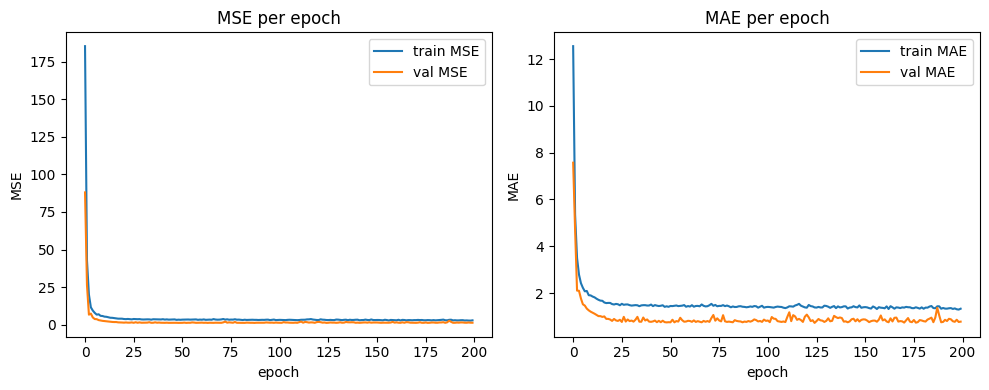

In [33]:
import matplotlib.pyplot as plt
from pathlib import Path


def plot_pretrain_history(history, out_dir: Path | None = None, show: bool = False):
    """Plot train/val MSE and MAE curves from history dict/CSV/DataFrame."""
    if history is None:
        print("No history provided.")
        return None

    if isinstance(history, (str, Path)):
        df = pd.read_csv(history)
    elif isinstance(history, dict):
        df = pd.DataFrame(history)
    else:
        df = history.copy()

    if df.empty:
        print("History is empty; nothing to plot.")
        return None

    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
    axes[0].plot(df["train_loss"], label="train MSE")
    axes[0].plot(df["val_loss"], label="val MSE")
    axes[0].set_title("MSE per epoch")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("MSE")
    axes[0].legend()

    axes[1].plot(df["train_mae"], label="train MAE")
    axes[1].plot(df["val_mae"], label="val MAE")
    axes[1].set_title("MAE per epoch")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("MAE")
    axes[1].legend()

    plt.tight_layout()
    saved_path = None
    if out_dir is not None:
        out_dir.mkdir(parents=True, exist_ok=True)
        saved_path = out_dir / "pretrain_history.png"
        fig.savefig(saved_path, dpi=150, bbox_inches="tight")
        print(f"Saved pretraining curves to {saved_path}")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return saved_path, df


# Auto-plot using in-memory history or saved history table
if PRETRAIN_RUN and PRETRAIN_RUN.get("history"):
    plot_pretrain_history(PRETRAIN_RUN["history"], paths.plots, show=True)
elif HISTORY_PATH.exists():
    hist_df = pd.read_csv(HISTORY_PATH)
    if PRETRAIN_RUN and PRETRAIN_RUN.get("run_id"):
        hist_df = hist_df[hist_df["run_id"] == PRETRAIN_RUN["run_id"]]
    elif not hist_df.empty:
        last_run = hist_df["run_id"].dropna().iloc[-1]
        hist_df = hist_df[hist_df["run_id"] == last_run]

    if hist_df.empty:
        print("History table found, but no matching pretrain run.")
    else:
        plot_pretrain_history(hist_df, paths.plots)
else:
    print("No pretraining history available to plot.")

## Zero-shot evaluation
Stub for evaluating the pretrained checkpoint on yearly buckets (2005–2020) and the aggregated post-2005 set. Uses the saved preprocessing artifacts for consistent encoding.

Zero-shot eval plan/storage:
- Load pretrained checkpoint + feature artifacts (from in-memory run or disk) and move to `cfg.device`.
- For each eval bucket (per-year + `post_2005_plus`), transform with saved encoders/scaler, build non-shuffled loader, and compute RMSE/MAE/MSE.
- Record per-bucket metrics and `n` to a tidy `DataFrame`; save to `paths.results/zero_shot.csv` (and optionally JSON if needed).
- Keep outputs reusable for plots and comparison against finetuned variants (add `method=zero_shot`).

In [34]:
def restore_pretrained(train_cfg: TrainConfig, ckpt_path: Path) -> torch.nn.Module:
    """Reload a pretrained model from disk using the saved train config."""
    model = TabularRegressor(
        mode=train_cfg.mode,
        input_dim=train_cfg.input_dim,
        num_dim=train_cfg.num_dim,
        cat_dim=train_cfg.cat_dim,
        encoder_hidden=train_cfg.encoder_hidden,
        head_hidden=train_cfg.head_hidden,
        dropout=train_cfg.dropout,
    ).to(train_cfg.device)
    load_checkpoint(model, ckpt_path, map_location=train_cfg.device)
    return model


def evaluate_zero_shot(pretrain_run: Dict[str, object] | None, splits: Dict[str, object], cfg: ExperimentConfig, paths: NotebookPaths):
    """Evaluate the pretrained checkpoint on each yearly bucket and post-2005 aggregate."""
    run = pretrain_run or PRETRAIN_RUN
    if run is None:
        print("No pretraining run available yet. Execute run_pretrain_shared(...) first or load from disk.")
        return None

    artifacts = run.get("features", {}).get("artifacts")
    if artifacts is None:
        artifacts = load_artifacts(paths.checkpoints / "pretrain_shared_artifacts.pt")

    model = run.get("model")
    if model is None:
        model = restore_pretrained(run["train_cfg"], run["ckpt_path"])
    device = run.get("train_cfg", BASE_SHARED_TRAIN).device
    model.to(device)

    results = []
    for year_key, df in splits["eval_buckets"].items():
        if df.empty:
            continue
        X, y = apply_feature_artifacts(df, artifacts)
        loader = tensor_loader_from_arrays(X, y, batch_size=cfg.batch_size, shuffle=False)
        metrics = evaluate_shared(model, loader, device)
        results.append(
            {
                "method": "zero_shot",
                "year": year_key,
                **metrics,
                "n": len(df),
            }
        )

    results_df = pd.DataFrame(results)

    run_meta = {
        "method": "zero_shot",
        "variant": "zero_shot",
        "epochs": run.get("train_cfg", BASE_SHARED_TRAIN).epochs,
        "lr": run.get("train_cfg", BASE_SHARED_TRAIN).lr,
        "data_frac": None,
        "batch_size": cfg.batch_size,
        "seed": cfg.seed,
        "device": device,
        "pretrain_ckpt": str(run.get("ckpt_path")) if run.get("ckpt_path") else None,
        "artifacts_path": str(paths.checkpoints / "pretrain_shared_artifacts.pt"),
    }
    run_id = record_run_metadata(run_meta)
    out_path = record_bucket_metrics(run_id, "zero_shot", results_df)
    return results_df, out_path


In [35]:
# Run zero-shot evaluation on yearly buckets using the pretrained checkpoint
RUN_ZERO_SHOT = True

if RUN_ZERO_SHOT:
    zs = evaluate_zero_shot(PRETRAIN_RUN, SPLITS, cfg, paths)
    if zs is not None:
        zero_shot_df, zero_path = zs
        print(zero_shot_df.head())
        print(f"Zero-shot metrics saved to {zero_path}")
    else:
        print("Zero-shot eval skipped; no pretrained checkpoint available.")
else:
    print("Skipped zero-shot eval.")

      method  year       mse       mae      rmse    n
0  zero_shot  2005  0.745172  0.625500  0.863233  170
1  zero_shot  2006  0.796009  0.639933  0.892193  163
2  zero_shot  2007  0.881359  0.635189  0.938807  157
3  zero_shot  2008  0.991311  0.655030  0.995646  171
4  zero_shot  2009  1.511079  0.812232  1.229260  171
Zero-shot metrics saved to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\pretrained_finetune\results\bucket_metrics.csv


      method  year  sample       mse       mae      rmse   n
0  zero_shot  2005       0  0.496240  0.573797  0.704443  34
1  zero_shot  2005       1  1.077133  0.738972  1.037850  34
2  zero_shot  2005       2  0.885015  0.675521  0.940752  34
3  zero_shot  2005       3  1.999023  0.969030  1.413868  34
4  zero_shot  2005       4  0.376941  0.523928  0.613955  34
Sampled zero-shot metrics saved to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\pretrained_finetune\results\zero_shot_samples_ns50_frac0.2.csv


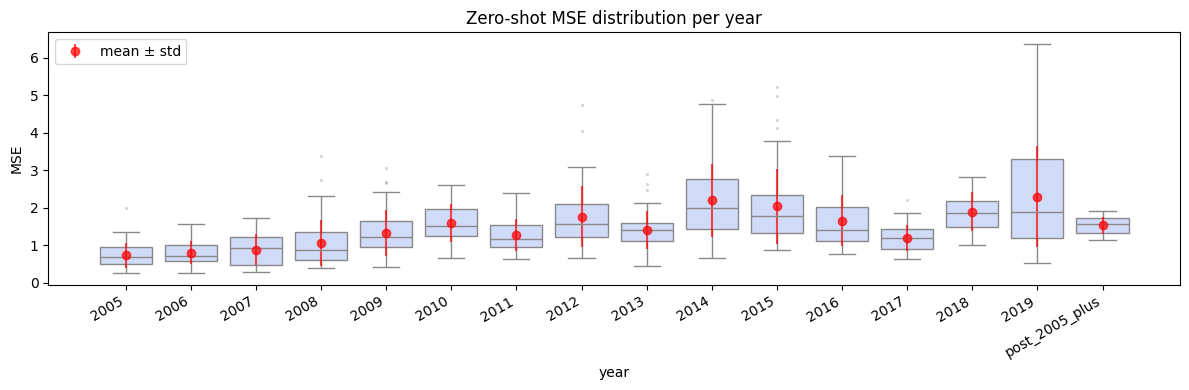

Saved boxplots to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\pretrained_finetune\plots\zero_shot_mse_boxplots.png


In [36]:
def evaluate_zero_shot_samples(
    pretrain_run: Dict[str, object] | None,
    splits: Dict[str, object],
    cfg: ExperimentConfig,
    paths: NotebookPaths,
    n_samples: int = 10,
    sample_frac: float = 0.5,
    replace: bool = True,
    seed: int | None = None,
):
    """Repeatedly sample each eval bucket and compute metrics for boxplots."""
    run = pretrain_run or PRETRAIN_RUN
    if run is None:
        print("No pretraining run available; run pretraining first or load checkpoint.")
        return None

    rng_seed = seed if seed is not None else cfg.seed

    artifacts = run.get("features", {}).get("artifacts")
    if artifacts is None:
        artifacts = load_artifacts(paths.checkpoints / "pretrain_shared_artifacts.pt")

    model = run.get("model")
    if model is None:
        model = restore_pretrained(run["train_cfg"], run["ckpt_path"])
    device = run.get("train_cfg", BASE_SHARED_TRAIN).device
    model.to(device)

    results = []
    for year_key, df in splits["eval_buckets"].items():
        if df.empty:
            continue
        for i in range(n_samples):
            sample_df = df.sample(
                frac=sample_frac,
                replace=replace,
                random_state=rng_seed + i,
            )
            if sample_df.empty:
                continue
            X, y = apply_feature_artifacts(sample_df, artifacts)
            loader = tensor_loader_from_arrays(X, y, batch_size=cfg.batch_size, shuffle=False)
            metrics = evaluate_shared(model, loader, device)
            results.append(
                {
                    "method": "zero_shot",
                    "year": year_key,
                    "sample": i,
                    **metrics,
                    "n": len(sample_df),
                }
            )

    samples_df = pd.DataFrame(results)
    if samples_df.empty:
        print("No sampled metrics produced.")
        return None

    out_path = paths.results / f"zero_shot_samples_ns{n_samples}_frac{sample_frac}.csv"
    samples_df.to_csv(out_path, index=False)
    return samples_df, out_path


def plot_zero_shot_boxplots(
    samples_df: pd.DataFrame,
    metric: str = "rmse",
    out_dir: Path | None = None,
    show: bool = False,
    prefix: str = "zero_shot",
    title_prefix: str = "Zero-shot",
):
    if samples_df is None or samples_df.empty:
        print("No sample data to plot.")
        return None

    samples_df = samples_df.assign(year_label=samples_df["year"].astype(str))
    save_path = out_dir / f"{prefix}_{metric}_boxplots.png" if out_dir else None

    _, _, summary = boxplot_by_group(
        samples_df,
        group_col="year_label",
        value_col=metric,
        order=None,  # util handles numeric-first ordering
        title=f"{title_prefix} {metric.upper()} distribution per year",
        xlabel="year",
        ylabel=metric.upper(),
        color="#c9d8ff",
        save_path=save_path,
        show=show,
    )

    if save_path:
        print(f"Saved boxplots to {save_path}")

    return save_path, summary


# Run sampled zero-shot eval + boxplots
RUN_ZERO_SHOT_SAMPLES = True
N_SAMPLES = 50
SAMPLE_FRAC = 0.2
SAMPLE_METRIC = "mse"
SHOW_ZERO_SHOT_PLOTS = True  # set True to display inline

if RUN_ZERO_SHOT_SAMPLES:
    zs_samples = evaluate_zero_shot_samples(
        PRETRAIN_RUN,
        SPLITS,
        cfg,
        paths,
        n_samples=N_SAMPLES,
        sample_frac=SAMPLE_FRAC,
        replace=True,
        seed=cfg.seed,
    )
    if zs_samples is not None:
        samples_df, samples_path = zs_samples
        print(samples_df.head())
        print(f"Sampled zero-shot metrics saved to {samples_path}")
        plot_zero_shot_boxplots(
            samples_df,
            metric=SAMPLE_METRIC,
            out_dir=paths.plots,
            show=SHOW_ZERO_SHOT_PLOTS,
        )
    else:
        print("Skipped sampled zero-shot eval; no data produced.")
else:
    print("Skipped zero-shot sampling.")


## Fine-tuning variants
Configurations for full finetuning, head-only, gradual unfreeze, and adapters/LoRA. These functions will reuse the pretrained checkpoint + artifacts and track wall-clock and configs for later aggregation.

In [37]:
import time

from src.models.heads import RegressionHead
from src.models.adapters import AdapterConfig, apply_adapters_to_model


FINETUNE_VARIANTS = {
    "full_finetune": {
        "freeze_encoder_epochs": 0,
        "reinit_head": False,
        "description": "Unfreeze everything; shorter schedule + lower LR",
    },
    "head_only": {
        "freeze_encoder_epochs": None,  # keep encoder frozen for all epochs
        "reinit_head": False,
        "freeze_norms": True,
        "description": "Freeze encoder; finetune pretrained head",
    },
    "gradual_unfreeze": {
        "freeze_encoder_epochs": 10,
        "reinit_head": False,
        "description": "Start frozen, unfreeze after 1 epoch (adjust as needed)",
    },
    "adapters_lora": {
        "freeze_encoder_epochs": 0,
        "reinit_head": False,
        "freeze_norms": True,
        "description": "LoRA adapters on encoder + head (train base + adapters)",
        "adapter": "lora",
        "adapter_cfg": {"rank": 8, "alpha": 16.0, "dropout": 0.0, "train_bias": False, "train_base": False},
    },
    "adapters_dora": {
        "freeze_encoder_epochs": 0,
        "reinit_head": False,
        "freeze_norms": True,
        "description": "DoRA adapters on encoder + head (train base + adapters)",
        "adapter": "dora",
        "adapter_cfg": {"rank": 8, "alpha": 16.0, "dropout": 0.0, "train_bias": False, "train_base": False},
    },
}


def prep_finetune_arrays_from_splits(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
    artifacts: Dict[str, object],
) -> Dict[str, np.ndarray]:
    """Transform pre-split post-2005 data using pretrained artifacts (no refit)."""
    X_train, y_train = apply_feature_artifacts(train_df, artifacts)
    X_val, y_val = apply_feature_artifacts(val_df, artifacts)
    X_test, y_test = apply_feature_artifacts(test_df, artifacts)
    return {
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test,
    }


def _set_encoder_requires_grad(model: torch.nn.Module, requires_grad: bool) -> None:
    for param in model.encoder.parameters():
        param.requires_grad = requires_grad


def _make_optimizer(model: torch.nn.Module, lr: float) -> torch.optim.Optimizer:
    params = [p for p in model.parameters() if p.requires_grad]
    return torch.optim.Adam(params, lr=lr)


def _reinit_head(model: torch.nn.Module, head_hidden: Tuple[int, ...], dropout: float) -> None:
    first_linear = next((m for m in model.head.modules() if isinstance(m, torch.nn.Linear)), None)
    input_dim = first_linear.in_features if first_linear is not None else None
    model.head = RegressionHead(input_dim, hidden_dims=head_hidden, dropout=dropout).to(next(model.parameters()).device)


_NORM_TYPES = (
    torch.nn.BatchNorm1d,
    torch.nn.BatchNorm2d,
    torch.nn.BatchNorm3d,
    torch.nn.LayerNorm,
    torch.nn.GroupNorm,
)


def set_norm_eval(model: torch.nn.Module) -> None:
    """Put normalization layers in eval mode and freeze their parameters."""
    for module in model.modules():
        if isinstance(module, _NORM_TYPES):
            module.eval()
            for param in module.parameters():
                param.requires_grad = False


def count_params(model: torch.nn.Module) -> Dict[str, float | int | None]:
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    ratio = (trainable / total) if total else None
    return {"total_params": total, "trainable_params": trainable, "trainable_ratio": ratio}


def count_model_params(model: torch.nn.Module) -> Dict[str, float | int | None]:
    # Backwards-compatible alias.
    return count_params(model)


def finetune_shared_model(
    model: torch.nn.Module,
    train_cfg: TrainConfig,
    train_loader: torch.utils.data.DataLoader,
    val_loader: torch.utils.data.DataLoader,
    use_adapters: bool = False,
    freeze_norms: bool = False,
    on_epoch_end: Callable[[int, Dict[str, List[float]], int], None] | None = None,
) -> Tuple[torch.nn.Module, Dict[str, List[float]], float, Dict[str, float | int | None]]:
    """Finetune loop for shared encoder models loaded from a pretrained checkpoint."""
    loss_fn = torch.nn.MSELoss()
    history = {"train_loss": [], "val_loss": [], "train_mae": [], "val_mae": []}

    if train_cfg.epochs <= 0:
        stats = {"steps": 0, "steps_per_sec": None, "peak_mem_bytes": None}
        return model, history, 0.0, stats

    if not use_adapters:
        freeze_all_epochs = train_cfg.freeze_encoder_epochs is None
        if freeze_all_epochs:
            _set_encoder_requires_grad(model, False)
        elif train_cfg.freeze_encoder_epochs and train_cfg.freeze_encoder_epochs > 0:
            _set_encoder_requires_grad(model, False)

    opt = _make_optimizer(model, train_cfg.lr)
    start = time.perf_counter()
    steps = 0
    if train_cfg.device.startswith("cuda") and torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    for epoch in range(1, train_cfg.epochs + 1):
        model.train()
        if freeze_norms:
            set_norm_eval(model)
        train_losses, train_mae = [], []
        for xb, yb in train_loader:
            xb = xb.to(train_cfg.device)
            yb = yb.to(train_cfg.device)
            pred = model(xb).unsqueeze(1)
            loss = loss_fn(pred, yb.unsqueeze(1))
            opt.zero_grad()
            loss.backward()
            opt.step()
            train_losses.append(loss.item())
            train_mae.append(torch.abs(pred - yb.unsqueeze(1)).mean().item())
            steps += 1

        model.eval()
        val_losses, val_mae = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(train_cfg.device)
                yb = yb.to(train_cfg.device)
                pred = model(xb).unsqueeze(1)
                val_losses.append(loss_fn(pred, yb.unsqueeze(1)).item())
                val_mae.append(torch.abs(pred - yb.unsqueeze(1)).mean().item())

        history["train_loss"].append(sum(train_losses) / len(train_losses))
        history["val_loss"].append(sum(val_losses) / len(val_losses))
        history["train_mae"].append(sum(train_mae) / len(train_mae))
        history["val_mae"].append(sum(val_mae) / len(val_mae))

        if epoch % 10 == 0 or epoch == 1:
            print(
                f"Epoch {epoch:03d} | train MSE {history['train_loss'][-1]:.4f} | "
                f"val MSE {history['val_loss'][-1]:.4f} | "
                f"train MAE {history['train_mae'][-1]:.4f} | "
                f"val MAE {history['val_mae'][-1]:.4f}"
            )

        if on_epoch_end is not None:
            on_epoch_end(epoch, history, steps)

        if (
            not use_adapters
            and train_cfg.freeze_encoder_epochs is not None
            and train_cfg.freeze_encoder_epochs > 0
            and epoch == train_cfg.freeze_encoder_epochs
        ):
            _set_encoder_requires_grad(model, True)
            opt = _make_optimizer(model, train_cfg.lr)

    wall_time_s = time.perf_counter() - start
    steps_per_sec = steps / wall_time_s if wall_time_s > 0 else None
    peak_mem_bytes = None
    if train_cfg.device.startswith("cuda") and torch.cuda.is_available():
        peak_mem_bytes = int(torch.cuda.max_memory_allocated())
    stats = {
        "steps": steps,
        "steps_per_sec": steps_per_sec,
        "peak_mem_bytes": peak_mem_bytes,
    }
    return model, history, wall_time_s, stats


def run_finetune_variant(
    name: str,
    splits: Dict[str, object],
    cfg: ExperimentConfig,
    paths: NotebookPaths,
    pretrain_run: Dict[str, object] | None,
    data_frac: float,
    epochs: int,
    lr: float,
):
    """Run a finetune variant starting from the pretrained checkpoint."""
    variant = FINETUNE_VARIANTS[name]
    run = pretrain_run or PRETRAIN_RUN
    if run is None:
        print("No pretrained checkpoint yet; run pretraining first.")
        return None

    set_deterministic_seed(cfg.seed)

    artifacts = run.get("features", {}).get("artifacts")
    if artifacts is None:
        artifacts = load_artifacts(paths.checkpoints / "pretrain_shared_artifacts.pt")

    split_dfs = load_post2005_split_dfs()
    split_dfs = maybe_downsample_splits(split_dfs, frac=data_frac, seed=cfg.seed)
    ft_arrays = prep_finetune_arrays_from_splits(
        split_dfs["train"],
        split_dfs["val"],
        split_dfs["test"],
        artifacts,
    )

    train_cfg = train_config_for_shared(
        input_dim=ft_arrays["X_train"].shape[1],
        epochs=epochs,
        lr=lr,
        freeze_encoder_epochs=variant["freeze_encoder_epochs"],
    )

    train_loader, val_loader = make_loaders(
        ft_arrays["X_train"],
        ft_arrays["y_train"],
        ft_arrays["X_val"],
        ft_arrays["y_val"],
        batch_size=train_cfg.batch_size,
        separate=False,
    )

    model = restore_pretrained(run["train_cfg"], run["ckpt_path"])
    if variant["reinit_head"]:
        _reinit_head(model, head_hidden=train_cfg.head_hidden, dropout=train_cfg.dropout)

    use_adapters = False
    adapter_type = variant.get("adapter")
    if adapter_type:
        adapter_cfg = AdapterConfig(adapter=adapter_type, **variant.get("adapter_cfg", {}))
        apply_adapters_to_model(model, adapter_cfg)
        use_adapters = True

    freeze_norms = bool(variant.get("freeze_norms", False))
    if freeze_norms:
        set_norm_eval(model)

    param_counts = count_params(model)
    model, history, wall_time_s, train_stats = finetune_shared_model(
        model,
        train_cfg,
        train_loader,
        val_loader,
        use_adapters=use_adapters,
        freeze_norms=freeze_norms,
    )

    test_loader = tensor_loader_from_arrays(
        ft_arrays["X_test"],
        ft_arrays["y_test"],
        batch_size=train_cfg.batch_size,
        shuffle=False,
    )
    test_metrics = evaluate_shared(model, test_loader, train_cfg.device)

    ckpt_path = paths.checkpoints / f"finetune_{name}_epochs{epochs}_frac{data_frac}.pt"
    save_checkpoint(model, ckpt_path)

    run_meta = {
        **asdict(train_cfg),
        "method": name,
        "variant": name,
        "description": variant["description"],
        "data_frac": data_frac,
        "epochs": epochs,
        "lr": lr,
        "seed": cfg.seed,
        "pretrain_ckpt": str(run["ckpt_path"]),
        "wall_time_s": wall_time_s,
        "steps": train_stats.get("steps"),
        "steps_per_sec": train_stats.get("steps_per_sec"),
        "peak_mem_bytes": train_stats.get("peak_mem_bytes"),
        "total_params": param_counts.get("total_params"),
        "trainable_params": param_counts.get("trainable_params"),
        "trainable_ratio": param_counts.get("trainable_ratio"),
        "adapter": adapter_type,
        "adapter_cfg": variant.get("adapter_cfg"),
        "n_train": len(ft_arrays["y_train"]),
        "n_val": len(ft_arrays["y_val"]),
        "n_test": len(ft_arrays["y_test"]),
        "artifacts_path": str(paths.checkpoints / "pretrain_shared_artifacts.pt"),
        "ckpt_path": str(ckpt_path),
    }
    run_id = record_run_metadata(run_meta)
    record_history(run_id, history, SAVE_EPOCH_HISTORY)
    record_test_metrics(
        run_id,
        name,
        test_metrics,
        extra_meta={
            "epochs": epochs,
            "data_frac": data_frac,
            "lr": lr,
            "seed": cfg.seed,
            "wall_time_s": wall_time_s,
            "total_params": param_counts.get("total_params"),
            "trainable_params": param_counts.get("trainable_params"),
            "trainable_ratio": param_counts.get("trainable_ratio"),
        },
    )

    return {
        "run_id": run_id,
        "variant": name,
        "description": variant["description"],
        "data_frac": data_frac,
        "epochs": epochs,
        "lr": lr,
        "seed": cfg.seed,
        "freeze_encoder_epochs": train_cfg.freeze_encoder_epochs,
        "reinit_head": variant["reinit_head"],
        "adapter": adapter_type,
        "adapter_cfg": variant.get("adapter_cfg"),
        "n_train": len(ft_arrays["y_train"]),
        "n_val": len(ft_arrays["y_val"]),
        "n_test": len(ft_arrays["y_test"]),
        "model": model,
        "history": history,
        "train_cfg": train_cfg,
        "ckpt_path": ckpt_path,
        "artifacts_path": paths.checkpoints / "pretrain_shared_artifacts.pt",
        "wall_time_s": wall_time_s,
        "test_metrics": test_metrics,
        "train_stats": train_stats,
        "param_counts": param_counts,
    }


def run_finetune_variant_sweep(
    name: str,
    splits: Dict[str, object],
    cfg: ExperimentConfig,
    paths: NotebookPaths,
    pretrain_run: Dict[str, object] | None,
    data_frac: float,
    epoch_sweep: List[int],
    lr: float,
) -> List[Dict[str, object]]:
    """Run a finetune variant once and save checkpoints for each epoch in the sweep."""
    if not epoch_sweep:
        return []

    variant = FINETUNE_VARIANTS[name]
    run = pretrain_run or PRETRAIN_RUN
    if run is None:
        print("No pretrained checkpoint yet; run pretraining first.")
        return []

    set_deterministic_seed(cfg.seed)

    artifacts = run.get("features", {}).get("artifacts")
    if artifacts is None:
        artifacts = load_artifacts(paths.checkpoints / "pretrain_shared_artifacts.pt")

    split_dfs = load_post2005_split_dfs()
    split_dfs = maybe_downsample_splits(split_dfs, frac=data_frac, seed=cfg.seed)
    ft_arrays = prep_finetune_arrays_from_splits(
        split_dfs["train"],
        split_dfs["val"],
        split_dfs["test"],
        artifacts,
    )

    target_epochs = sorted(set(epoch_sweep))
    max_epochs = max(target_epochs)

    train_cfg = train_config_for_shared(
        input_dim=ft_arrays["X_train"].shape[1],
        epochs=max_epochs,
        lr=lr,
        freeze_encoder_epochs=variant["freeze_encoder_epochs"],
    )

    train_loader, val_loader = make_loaders(
        ft_arrays["X_train"],
        ft_arrays["y_train"],
        ft_arrays["X_val"],
        ft_arrays["y_val"],
        batch_size=train_cfg.batch_size,
        separate=False,
    )

    test_loader = tensor_loader_from_arrays(
        ft_arrays["X_test"],
        ft_arrays["y_test"],
        batch_size=train_cfg.batch_size,
        shuffle=False,
    )

    model = restore_pretrained(run["train_cfg"], run["ckpt_path"])
    if variant["reinit_head"]:
        _reinit_head(model, head_hidden=train_cfg.head_hidden, dropout=train_cfg.dropout)

    use_adapters = False
    adapter_type = variant.get("adapter")
    if adapter_type:
        adapter_cfg = AdapterConfig(adapter=adapter_type, **variant.get("adapter_cfg", {}))
        apply_adapters_to_model(model, adapter_cfg)
        use_adapters = True

    freeze_norms = bool(variant.get("freeze_norms", False))
    if freeze_norms:
        set_norm_eval(model)

    runs: List[Dict[str, object]] = []
    start_time = time.perf_counter()
    param_counts = count_params(model)

    def record_epoch(epoch: int, history: Dict[str, List[float]], steps_so_far: int) -> None:
        wall_time_s = 0.0 if epoch == 0 else time.perf_counter() - start_time
        steps_per_sec = (steps_so_far / wall_time_s) if wall_time_s > 0 else None
        peak_mem_bytes = None
        if train_cfg.device.startswith("cuda") and torch.cuda.is_available():
            peak_mem_bytes = int(torch.cuda.max_memory_allocated())
        train_stats = {
            "steps": steps_so_far,
            "steps_per_sec": steps_per_sec,
            "peak_mem_bytes": peak_mem_bytes,
        }
        test_metrics = evaluate_shared(model, test_loader, train_cfg.device)
        ckpt_path = paths.checkpoints / f"finetune_{name}_epochs{epoch}_frac{data_frac}.pt"
        save_checkpoint(model, ckpt_path)

        history_snapshot = {key: values[:epoch] for key, values in history.items()}

        epoch_cfg = train_config_for_shared(
            input_dim=ft_arrays["X_train"].shape[1],
            epochs=epoch,
            lr=lr,
            freeze_encoder_epochs=variant["freeze_encoder_epochs"],
        )
        run_meta = {
            **asdict(epoch_cfg),
            "method": name,
            "variant": name,
            "description": variant["description"],
            "data_frac": data_frac,
            "epochs": epoch,
            "lr": lr,
            "seed": cfg.seed,
            "pretrain_ckpt": str(run["ckpt_path"]),
            "wall_time_s": wall_time_s,
            "steps": train_stats.get("steps"),
            "steps_per_sec": train_stats.get("steps_per_sec"),
            "peak_mem_bytes": train_stats.get("peak_mem_bytes"),
            "total_params": param_counts.get("total_params"),
            "trainable_params": param_counts.get("trainable_params"),
            "trainable_ratio": param_counts.get("trainable_ratio"),
            "adapter": adapter_type,
            "adapter_cfg": variant.get("adapter_cfg"),
            "n_train": len(ft_arrays["y_train"]),
            "n_val": len(ft_arrays["y_val"]),
            "n_test": len(ft_arrays["y_test"]),
            "artifacts_path": str(paths.checkpoints / "pretrain_shared_artifacts.pt"),
            "ckpt_path": str(ckpt_path),
        }
        run_id = record_run_metadata(run_meta)
        record_history(run_id, history_snapshot, SAVE_EPOCH_HISTORY)
        record_test_metrics(
            run_id,
            name,
            test_metrics,
            extra_meta={
                "epochs": epoch,
                "data_frac": data_frac,
                "lr": lr,
                "seed": cfg.seed,
                "wall_time_s": wall_time_s,
                "total_params": param_counts.get("total_params"),
                "trainable_params": param_counts.get("trainable_params"),
                "trainable_ratio": param_counts.get("trainable_ratio"),
            },
        )

        runs.append(
            {
                "run_id": run_id,
                "variant": name,
                "description": variant["description"],
                "data_frac": data_frac,
                "epochs": epoch,
                "lr": lr,
                "freeze_encoder_epochs": epoch_cfg.freeze_encoder_epochs,
                "reinit_head": variant["reinit_head"],
                "adapter": adapter_type,
                "adapter_cfg": variant.get("adapter_cfg"),
                "seed": cfg.seed,
                "total_params": param_counts.get("total_params"),
                "trainable_params": param_counts.get("trainable_params"),
                "trainable_ratio": param_counts.get("trainable_ratio"),
                "n_train": len(ft_arrays["y_train"]),
                "n_val": len(ft_arrays["y_val"]),
                "n_test": len(ft_arrays["y_test"]),
                "model": model,
                "history": history_snapshot,
                "train_cfg": epoch_cfg,
                "ckpt_path": ckpt_path,
                "artifacts_path": paths.checkpoints / "pretrain_shared_artifacts.pt",
                "wall_time_s": wall_time_s,
                "test_metrics": test_metrics,
                "train_stats": train_stats,
            }
        )

    if 0 in target_epochs:
        record_epoch(0, {"train_loss": [], "val_loss": [], "train_mae": [], "val_mae": []}, 0)

    def on_epoch_end(epoch: int, history: Dict[str, List[float]], steps_so_far: int) -> None:
        if epoch in target_epochs:
            record_epoch(epoch, history, steps_so_far)

    if max_epochs > 0:
        finetune_shared_model(
            model,
            train_cfg,
            train_loader,
            val_loader,
            use_adapters=use_adapters,
            freeze_norms=freeze_norms,
            on_epoch_end=on_epoch_end,
        )

    return runs


pd.DataFrame.from_dict(FINETUNE_VARIANTS, orient="index")

,freeze_encoder_epochs,reinit_head,description,freeze_norms,adapter,adapter_cfg
full_finetune,0.0,False,Unfreeze everything; shorter schedule + lower LR,NaN,NaN,NaN
head_only,NaN,False,Freeze encoder; finetune pretrained head,True,NaN,NaN
gradual_unfreeze,10.0,False,"Start frozen, unfreeze after 1 epoch (adjust a...",NaN,NaN,NaN
adapters_lora,0.0,False,LoRA adapters on encoder + head (train base + ...,True,lora,"{'rank': 8, 'alpha': 16.0, 'dropout': 0.0, 'tr..."
adapters_dora,0.0,False,DoRA adapters on encoder + head (train base + ...,True,dora,"{'rank': 8, 'alpha': 16.0, 'dropout': 0.0, 'tr..."


## Post-FT evaluation stub
Placeholder to reuse the zero-shot evaluation helper across finetuned checkpoints and annotate with method/epochs/data_frac/wall_time.

In [38]:
def resolve_artifacts_and_model(
    run: Dict[str, object],
    paths: NotebookPaths,
) -> Tuple[torch.nn.Module, Dict[str, object], str]:
    """Resolve artifacts and model for any run (pretrain or finetune)."""
    artifacts = run.get("features", {}).get("artifacts")
    if artifacts is None:
        artifacts_path = run.get("artifacts_path") or (paths.checkpoints / "pretrain_shared_artifacts.pt")
        artifacts = load_artifacts(artifacts_path)

    model = run.get("model")
    if model is None:
        model = restore_pretrained(run["train_cfg"], run["ckpt_path"])

    device = run.get("train_cfg", BASE_SHARED_TRAIN).device
    model.to(device)
    return model, artifacts, device


def evaluate_model_on_buckets(
    model: torch.nn.Module,
    artifacts: Dict[str, object],
    splits: Dict[str, object],
    cfg: ExperimentConfig,
    method: str,
    extra_meta: Dict[str, object] | None = None,
) -> pd.DataFrame:
    """Evaluate a model on each bucket using shared preprocessing artifacts."""
    results = []
    for year_key, df in splits["eval_buckets"].items():
        if df.empty:
            continue
        X, y = apply_feature_artifacts(df, artifacts)
        loader = tensor_loader_from_arrays(X, y, batch_size=cfg.batch_size, shuffle=False)
        metrics = evaluate_shared(model, loader, cfg.device)
        row = {"method": method, "year": year_key, **metrics, "n": len(df)}
        if extra_meta:
            row.update(extra_meta)
        results.append(row)

    return pd.DataFrame(results)


def evaluate_bucket_samples(
    model: torch.nn.Module,
    artifacts: Dict[str, object],
    splits: Dict[str, object],
    cfg: ExperimentConfig,
    method: str,
    n_samples: int = 10,
    sample_frac: float = 0.5,
    replace: bool = True,
    seed: int | None = None,
    extra_meta: Dict[str, object] | None = None,
) -> pd.DataFrame:
    """Sample each bucket repeatedly and compute metrics (for boxplots)."""
    rng_seed = seed if seed is not None else cfg.seed
    results = []
    for year_key, df in splits["eval_buckets"].items():
        if df.empty:
            continue
        for i in range(n_samples):
            sample_df = df.sample(
                frac=sample_frac,
                replace=replace,
                random_state=rng_seed + i,
            )
            if sample_df.empty:
                continue
            X, y = apply_feature_artifacts(sample_df, artifacts)
            loader = tensor_loader_from_arrays(X, y, batch_size=cfg.batch_size, shuffle=False)
            metrics = evaluate_shared(model, loader, cfg.device)
            row = {
                "method": method,
                "year": year_key,
                "sample": i,
                **metrics,
                "n": len(sample_df),
            }
            if extra_meta:
                row.update(extra_meta)
            results.append(row)

    return pd.DataFrame(results)


def summarize_finetune_runs(finetune_runs: List[Dict[str, object]]) -> pd.DataFrame:
    """Flatten finetune run metadata + test metrics for efficiency plots."""
    rows = []
    for run in finetune_runs:
        metrics = run.get("test_metrics", {})
        train_stats = run.get("train_stats", {})
        param_counts = run.get("param_counts", {})
        rows.append(
            {
                "method": run.get("variant"),
                "epochs": run.get("epochs"),
                "data_frac": run.get("data_frac"),
                "lr": run.get("lr"),
                "seed": run.get("seed"),
                "wall_time_s": run.get("wall_time_s"),
                "steps": train_stats.get("steps"),
                "steps_per_sec": train_stats.get("steps_per_sec"),
                "peak_mem_bytes": train_stats.get("peak_mem_bytes"),
                "total_params": param_counts.get("total_params"),
                "trainable_params": param_counts.get("trainable_params"),
                "trainable_ratio": param_counts.get("trainable_ratio"),
                "test_mse": metrics.get("mse"),
                "test_mae": metrics.get("mae"),
                "test_rmse": metrics.get("rmse"),
            }
        )
    return pd.DataFrame(rows)


def summarize_cost_quality(
    finetune_runs: List[Dict[str, object]],
    metric: str = "mse",
) -> pd.DataFrame:
    """Summarize cost/quality tradeoffs for each finetune run."""
    rows = []
    for run in finetune_runs:
        metrics = run.get("test_metrics", {})
        train_stats = run.get("train_stats", {})
        param_counts = run.get("param_counts", {})
        total_params = param_counts.get("total_params")
        trainable_params = param_counts.get("trainable_params")
        rows.append(
            {
                "method": run.get("variant"),
                "epochs": run.get("epochs"),
                "data_frac": run.get("data_frac"),
                f"test_{metric}": metrics.get(metric),
                "wall_time_s": run.get("wall_time_s"),
                "steps": train_stats.get("steps"),
                "steps_per_sec": train_stats.get("steps_per_sec"),
                "peak_mem_bytes": train_stats.get("peak_mem_bytes"),
                "total_params": total_params,
                "trainable_params": trainable_params,
                "trainable_ratio": (trainable_params / total_params) if total_params else None,
                "trainable_param_pct": (trainable_params / total_params) if total_params else None,
            }
        )
    return pd.DataFrame(rows)


def summarize_param_efficiency(runs_df: pd.DataFrame) -> pd.DataFrame:
    """One row per method with parameter-efficiency stats."""
    if runs_df is None or runs_df.empty:
        return pd.DataFrame()

    base_cols = ["method", "total_params", "trainable_params", "trainable_ratio"]
    available = [col for col in base_cols if col in runs_df.columns]
    if "method" not in available:
        return pd.DataFrame()

    summary = (
        runs_df[available]
        .drop_duplicates()
        .groupby("method", dropna=False)
        .first()
        .reset_index()
    )
    if "trainable_params" in summary.columns:
        summary = summary.sort_values("trainable_params")
    return summary


def aggregate_seed_metrics(
    results_df: pd.DataFrame,
    metric_col: str = "mse",
    group_cols: List[str] | None = None,
) -> pd.DataFrame:
    """Group by config and report mean/std for repeated seeds."""
    if results_df is None or results_df.empty:
        return pd.DataFrame()

    if metric_col not in results_df.columns:
        if f"test_{metric_col}" in results_df.columns:
            metric_col = f"test_{metric_col}"
        elif "test_mse" in results_df.columns:
            metric_col = "test_mse"
        elif "mse" in results_df.columns:
            metric_col = "mse"

    if group_cols is None:
        group_cols = ["method", "data_frac", "epochs", "lr"]

    group_cols = [col for col in group_cols if col in results_df.columns]
    if not group_cols or metric_col not in results_df.columns:
        return pd.DataFrame()

    summary = (
        results_df.groupby(group_cols, dropna=False)[metric_col]
        .agg(["mean", "std", "count"])
        .reset_index()
        .rename(columns={"mean": f"{metric_col}_mean", "std": f"{metric_col}_std", "count": "n_seeds"})
    )
    return summary


def plot_finetune_wall_time_by_frac(
    runs_df: pd.DataFrame,
    out_dir: Path | None = None,
    show: bool = False,
    prefix: str = "finetune",
):
    """Plot wall_time_s vs epochs with one line per data_frac."""
    if runs_df is None or runs_df.empty:
        print("No finetune runs to plot.")
        return None

    if "wall_time_s" not in runs_df.columns:
        print("Missing wall_time_s column.")
        return None

    from matplotlib.ticker import ScalarFormatter

    fig, ax = plt.subplots(figsize=(6, 4))
    for frac, group in runs_df.groupby("data_frac"):
        group = group.sort_values("epochs")
        ax.plot(group["epochs"], group["wall_time_s"], marker="o", label=f"frac={frac}")

    ax.set_title("Finetune efficiency: WALL_TIME_S vs epochs (by data fraction)\nEpoch 0 = Zero-shot baseline")
    ax.set_xlabel("epochs")
    ax.set_ylabel("WALL_TIME_S")
    ax.set_xscale("symlog", linthresh=1)
    xticks = sorted(set(runs_df["epochs"].tolist()))
    ax.set_xticks(xticks)
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.grid(True, alpha=0.3)
    ax.legend()

    saved_path = None
    if out_dir is not None:
        out_dir.mkdir(parents=True, exist_ok=True)
        saved_path = out_dir / f"{prefix}_efficiency_wall_time_s_by_frac.png"
        fig.savefig(saved_path, dpi=150, bbox_inches="tight")
        print(f"Saved wall-time efficiency plot to {saved_path}")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return saved_path


def evaluate_finetune_run(
    finetune_run: Dict[str, object],
    splits: Dict[str, object],
    cfg: ExperimentConfig,
    paths: NotebookPaths,
):
    """Evaluate a single finetune checkpoint on all yearly buckets."""
    if not finetune_run:
        print("No finetune run to evaluate yet.")
        return None

    model, artifacts, _ = resolve_artifacts_and_model(finetune_run, paths)
    param_counts = finetune_run.get("param_counts", {})
    meta = {
        "epochs": finetune_run.get("epochs"),
        "data_frac": finetune_run.get("data_frac"),
        "lr": finetune_run.get("lr"),
        "seed": finetune_run.get("seed"),
        "wall_time_s": finetune_run.get("wall_time_s"),
        "total_params": param_counts.get("total_params"),
        "trainable_params": param_counts.get("trainable_params"),
        "trainable_ratio": param_counts.get("trainable_ratio"),
    }
    results_df = evaluate_model_on_buckets(
        model=model,
        artifacts=artifacts,
        splits=splits,
        cfg=cfg,
        method=finetune_run.get("variant", "finetune"),
        extra_meta=meta,
    )

    out_path = paths.results / f"finetune_{finetune_run.get('variant', 'finetune')}_metrics.csv"
    results_df.to_csv(out_path, index=False)
    return results_df, out_path


def sample_frac_sweep_summary(
    model: torch.nn.Module,
    artifacts: Dict[str, object],
    splits: Dict[str, object],
    cfg: ExperimentConfig,
    method: str,
    sample_fracs: List[float],
    n_samples: int,
    metric: str = "mse",
    seed: int | None = None,
) -> pd.DataFrame:
    """Sweep sample_frac with fixed n_samples and summarize mean/std metric."""
    rows = []
    for frac in sample_fracs:
        samples_df = evaluate_bucket_samples(
            model=model,
            artifacts=artifacts,
            splits=splits,
            cfg=cfg,
            method=method,
            n_samples=n_samples,
            sample_frac=frac,
            replace=True,
            seed=seed,
            extra_meta={"sample_frac": frac},
        )
        if samples_df is None or samples_df.empty:
            continue
        rows.append(
            {
                "sample_frac": frac,
                "metric": metric,
                "mean": samples_df[metric].mean(),
                "std": samples_df[metric].std(),
            }
        )

    return pd.DataFrame(rows)


def plot_sample_frac_sweep(
    summary_df: pd.DataFrame,
    metric: str,
    out_dir: Path | None = None,
    show: bool = False,
    prefix: str = "finetune",
):
    """Plot mean metric vs sample_frac for a sweep."""
    if summary_df is None or summary_df.empty:
        print("No sample-frac sweep data to plot.")
        return None

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(summary_df["sample_frac"], summary_df["mean"], marker="o")
    ax.set_title(f"Sample-frac sweep: {metric.upper()} vs sample_frac")
    ax.set_xlabel("sample_frac")
    ax.set_ylabel(f"mean {metric.upper()}")
    ax.grid(True, alpha=0.3)

    saved_path = None
    if out_dir is not None:
        out_dir.mkdir(parents=True, exist_ok=True)
        saved_path = out_dir / f"{prefix}_sample_frac_sweep_{metric}.png"
        fig.savefig(saved_path, dpi=150, bbox_inches="tight")
        print(f"Saved sample-frac sweep plot to {saved_path}")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return saved_path


def plot_finetune_efficiency_by_frac(
    runs_df: pd.DataFrame,
    metric: str = "mse",
    out_dir: Path | None = None,
    show: bool = False,
    prefix: str = "finetune",
):
    if runs_df is None or runs_df.empty:
        print("No finetune runs to plot.")
        return None

    metric_col = f"test_{metric}"
    if metric_col not in runs_df.columns:
        print(f"Missing metric column: {metric_col}")
        return None

    from matplotlib.ticker import ScalarFormatter

    # ---- FIX: replace epoch 0 with small positive value ----
    eps = 0.5
    df = runs_df.copy()
    df["epochs_plot"] = df["epochs"].replace(0, eps)

    fig, ax = plt.subplots(figsize=(6, 4))

    for frac, group in df.groupby("data_frac"):
        group = group.sort_values("epochs_plot")
        ax.plot(
            group["epochs_plot"],
            group[metric_col],
            marker="o",
            label=f"frac={frac}",
        )

    ax.set_title(
        f"Finetune efficiency: {metric.upper()} vs epochs (by data fraction)\n"
    )
    ax.set_xlabel("epochs")
    ax.set_ylabel(metric.upper())

    # ---- TRUE log scale (no symlog) ----
    ax.set_xscale("log", base=2)

    # ---- Explicit ticks including epoch 0 ----
    xticks = [eps, 1, 2, 4, 8, 16, 32, 64, 128, 256]
    ax.set_xticks(xticks)
    ax.set_xticklabels(
        [
            "0\n(Zero-shot baseline)",
            "1",
            "2",
            "4",
            "8",
            "16",
            "32",
            "64",
            "128",
            "256",
        ]
    )

    ax.grid(True, alpha=0.3)
    ax.legend()

    saved_path = None
    if out_dir is not None:
        out_dir.mkdir(parents=True, exist_ok=True)
        saved_path = out_dir / f"{prefix}_efficiency_{metric}_by_frac.png"
        fig.savefig(saved_path, dpi=150, bbox_inches="tight")
        print(f"Saved efficiency-by-frac plot to {saved_path}")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return saved_path



In [39]:
def aggregate_results(
    zero_shot_df: pd.DataFrame | None,
    finetune_df: pd.DataFrame | None,
    paths: NotebookPaths,
):
    """Combine zero-shot + finetune outputs and persist tidy CSV/JSON."""
    frames = []
    if zero_shot_df is not None:
        frames.append(zero_shot_df.assign(method="zero_shot"))
    if finetune_df is not None:
        frames.append(finetune_df)

    if not frames:
        print("No results to aggregate yet.")
        return None

    all_results = pd.concat(frames, ignore_index=True)
    csv_path = paths.results / "all_results.csv"
    json_path = paths.results / "all_results.json"
    all_results.to_csv(csv_path, index=False)
    all_results.to_json(json_path, orient="records")
    return all_results, csv_path, json_path


## Fine-tune variants


### Head-only


Epoch 001 | train MSE 4.0662 | val MSE 1.1349 | train MAE 1.5872 | val MAE 0.8437
Epoch 010 | train MSE 3.8144 | val MSE 1.1395 | train MAE 1.5517 | val MAE 0.8472
Epoch 020 | train MSE 3.8005 | val MSE 1.1417 | train MAE 1.5302 | val MAE 0.8490
Epoch 030 | train MSE 3.9199 | val MSE 1.1543 | train MAE 1.5612 | val MAE 0.8584
Epoch 040 | train MSE 3.7752 | val MSE 1.1564 | train MAE 1.5424 | val MAE 0.8600
Epoch 050 | train MSE 3.6419 | val MSE 1.1123 | train MAE 1.4920 | val MAE 0.8222
Epoch 060 | train MSE 3.6751 | val MSE 1.1218 | train MAE 1.5224 | val MAE 0.8322
Epoch 070 | train MSE 3.7241 | val MSE 1.1951 | train MAE 1.5133 | val MAE 0.8843
Epoch 080 | train MSE 3.8609 | val MSE 1.1379 | train MAE 1.5596 | val MAE 0.8459
Epoch 090 | train MSE 3.7492 | val MSE 1.1210 | train MAE 1.5346 | val MAE 0.8311
Epoch 100 | train MSE 4.0400 | val MSE 1.1410 | train MAE 1.5968 | val MAE 0.8483
Epoch 110 | train MSE 3.7884 | val MSE 1.1464 | train MAE 1.5372 | val MAE 0.8525
Epoch 120 | trai

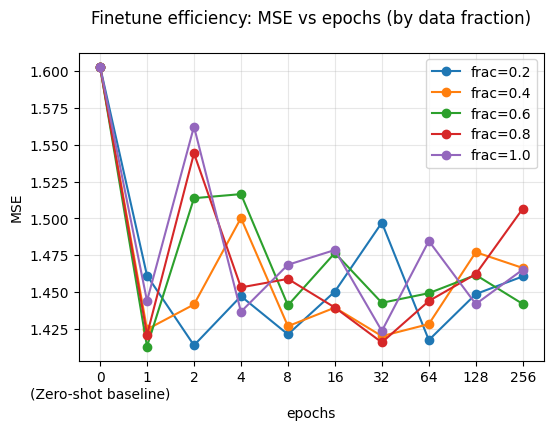

Saved wall-time efficiency plot to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\pretrained_finetune\plots\finetune_head_only_efficiency_wall_time_s_by_frac.png


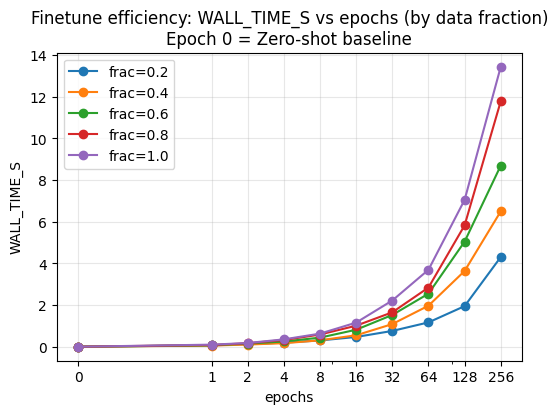

In [40]:
# Run head-only finetune + unified assessment
HEAD_ONLY_VARIANT = "head_only"
RUN_HEAD_ONLY = True
HEAD_ONLY_EPOCH_SWEEP = [0, 1, 2, 4, 8, 16, 32, 64, 128, 256]
HEAD_ONLY_DATA_FRAC_SWEEP = [1.0, 0.8, 0.6, 0.4, 0.2]
HEAD_ONLY_LR = cfg.finetune_lr
HEAD_ONLY_METRIC = "mse"
SHOW_HEAD_ONLY_PLOTS = True

if RUN_HEAD_ONLY:
    finetune_runs = []
    finetune_metrics = None

    for data_frac in HEAD_ONLY_DATA_FRAC_SWEEP:
        runs = run_finetune_variant_sweep(
            HEAD_ONLY_VARIANT,
            SPLITS,
            cfg,
            paths,
            PRETRAIN_RUN,
            data_frac=data_frac,
            epoch_sweep=HEAD_ONLY_EPOCH_SWEEP,
            lr=HEAD_ONLY_LR,
        )
        if runs:
            finetune_runs.extend(runs)

    if finetune_runs:
        eval_out = evaluate_finetune_run(finetune_runs[-1], SPLITS, cfg, paths)
        if eval_out is not None:
            finetune_metrics, finetune_path = eval_out
            print(f"Finetune metrics saved to {finetune_path}")

        runs_df = summarize_finetune_runs(finetune_runs)
        plot_finetune_efficiency_by_frac(
            runs_df,
            metric=HEAD_ONLY_METRIC,
            out_dir=paths.plots,
            show=SHOW_HEAD_ONLY_PLOTS,
            prefix=f"finetune_{finetune_runs[-1]['variant']}"
        )
        plot_finetune_wall_time_by_frac(
            runs_df,
            out_dir=paths.plots,
            show=SHOW_HEAD_ONLY_PLOTS,
            prefix=f"finetune_{finetune_runs[-1]['variant']}"
        )

        if finetune_metrics is not None:
            aggregate_results(globals().get("zero_shot_df"), finetune_metrics, paths)
    else:
        print("No finetune runs completed.")
else:
    print("Skipped head-only finetune run.")

### Full finetune


Epoch 001 | train MSE 4.0839 | val MSE 0.8555 | train MAE 1.5882 | val MAE 0.6895
Epoch 010 | train MSE 3.3301 | val MSE 0.7992 | train MAE 1.4564 | val MAE 0.6793
Epoch 020 | train MSE 3.3307 | val MSE 0.7577 | train MAE 1.4292 | val MAE 0.6529
Epoch 030 | train MSE 3.3857 | val MSE 0.8117 | train MAE 1.4628 | val MAE 0.6994
Epoch 040 | train MSE 3.2234 | val MSE 0.8035 | train MAE 1.4330 | val MAE 0.7014
Epoch 050 | train MSE 3.0662 | val MSE 0.7189 | train MAE 1.3838 | val MAE 0.6279
Epoch 060 | train MSE 2.9449 | val MSE 0.7204 | train MAE 1.3543 | val MAE 0.6357
Epoch 070 | train MSE 3.0837 | val MSE 0.7640 | train MAE 1.3837 | val MAE 0.6717
Epoch 080 | train MSE 2.9645 | val MSE 0.8051 | train MAE 1.3867 | val MAE 0.6940
Epoch 090 | train MSE 2.9736 | val MSE 0.8483 | train MAE 1.3801 | val MAE 0.7232
Epoch 100 | train MSE 3.1458 | val MSE 0.7774 | train MAE 1.4112 | val MAE 0.6830
Epoch 110 | train MSE 3.0343 | val MSE 1.0327 | train MAE 1.3972 | val MAE 0.8131
Epoch 120 | trai

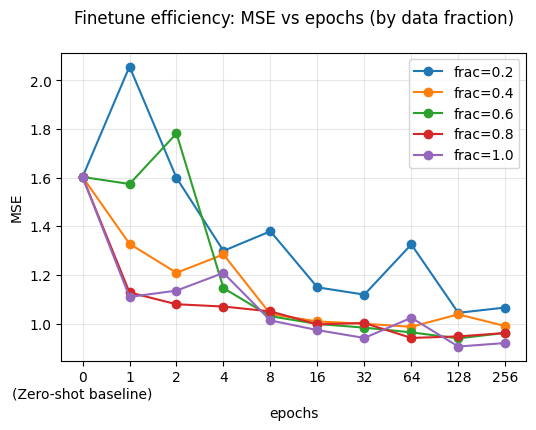

Saved wall-time efficiency plot to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\pretrained_finetune\plots\finetune_full_finetune_efficiency_wall_time_s_by_frac.png


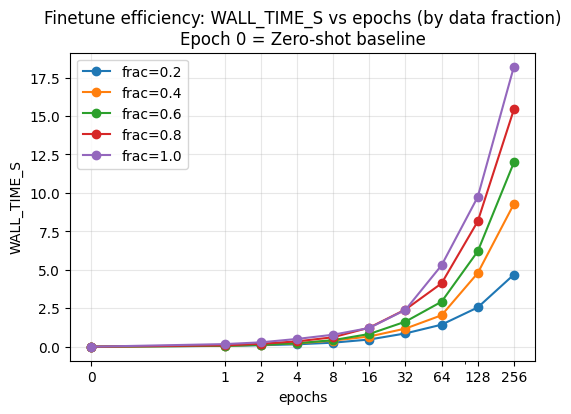

In [41]:
# Run full finetune + unified assessment
FULL_VARIANT = "full_finetune"
RUN_FULL_FINETUNE = True
FULL_EPOCH_SWEEP = [0, 1, 2, 4, 8, 16, 32, 64, 128, 256]
FULL_DATA_FRAC_SWEEP = [1.0, 0.8, 0.6, 0.4, 0.2]
FULL_LR = cfg.finetune_lr
FULL_METRIC = "mse"
SHOW_FULL_PLOTS = True

if RUN_FULL_FINETUNE:
    full_finetune_runs = []
    full_finetune_metrics = None

    for data_frac in FULL_DATA_FRAC_SWEEP:
        runs = run_finetune_variant_sweep(
            FULL_VARIANT,
            SPLITS,
            cfg,
            paths,
            PRETRAIN_RUN,
            data_frac=data_frac,
            epoch_sweep=FULL_EPOCH_SWEEP,
            lr=FULL_LR,
        )
        if runs:
            full_finetune_runs.extend(runs)

    if full_finetune_runs:
        eval_out = evaluate_finetune_run(full_finetune_runs[-1], SPLITS, cfg, paths)
        if eval_out is not None:
            full_finetune_metrics, finetune_path = eval_out
            print(f"Finetune metrics saved to {finetune_path}")

        runs_df = summarize_finetune_runs(full_finetune_runs)
        plot_finetune_efficiency_by_frac(
            runs_df,
            metric=FULL_METRIC,
            out_dir=paths.plots,
            show=SHOW_FULL_PLOTS,
            prefix=f"finetune_{FULL_VARIANT}"
        )
        plot_finetune_wall_time_by_frac(
            runs_df,
            out_dir=paths.plots,
            show=SHOW_FULL_PLOTS,
            prefix=f"finetune_{FULL_VARIANT}"
        )

        if full_finetune_metrics is not None:
            aggregate_results(globals().get("zero_shot_df"), full_finetune_metrics, paths)
    else:
        print("No full finetune runs completed.")
else:
    print("Skipped full finetune run.")

### Gradual unfreeze


Epoch 001 | train MSE 4.0662 | val MSE 1.1349 | train MAE 1.5872 | val MAE 0.8437
Epoch 010 | train MSE 3.8144 | val MSE 1.1395 | train MAE 1.5517 | val MAE 0.8472
Epoch 020 | train MSE 3.4109 | val MSE 0.7712 | train MAE 1.4433 | val MAE 0.6526
Epoch 030 | train MSE 3.4050 | val MSE 0.9129 | train MAE 1.4648 | val MAE 0.7578
Epoch 040 | train MSE 3.2268 | val MSE 0.8025 | train MAE 1.4329 | val MAE 0.6974
Epoch 050 | train MSE 3.0399 | val MSE 0.7124 | train MAE 1.3753 | val MAE 0.6245
Epoch 060 | train MSE 2.9500 | val MSE 0.7281 | train MAE 1.3592 | val MAE 0.6431
Epoch 070 | train MSE 3.0789 | val MSE 0.7620 | train MAE 1.3854 | val MAE 0.6719
Epoch 080 | train MSE 2.9830 | val MSE 0.7944 | train MAE 1.3905 | val MAE 0.6904
Epoch 090 | train MSE 2.9990 | val MSE 0.8476 | train MAE 1.3862 | val MAE 0.7227
Epoch 100 | train MSE 3.1606 | val MSE 0.7771 | train MAE 1.4153 | val MAE 0.6817
Epoch 110 | train MSE 3.0468 | val MSE 1.0166 | train MAE 1.3998 | val MAE 0.8066
Epoch 120 | trai

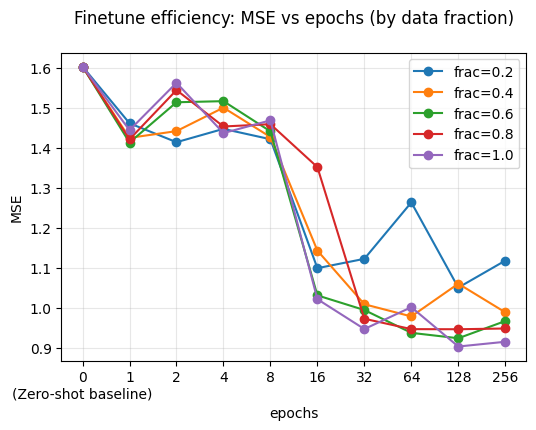

Saved wall-time efficiency plot to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\pretrained_finetune\plots\finetune_gradual_unfreeze_efficiency_wall_time_s_by_frac.png


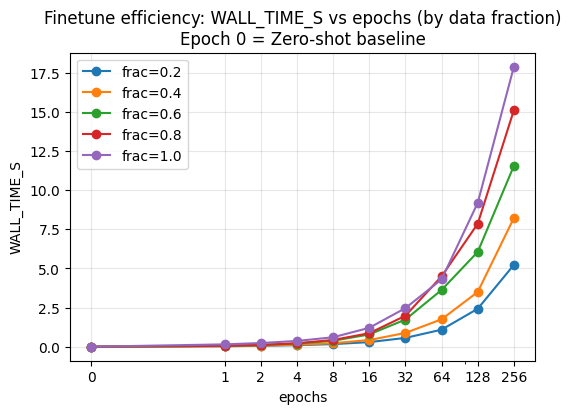

In [42]:
# Run gradual-unfreeze finetune + unified assessment
GRADUAL_VARIANT = "gradual_unfreeze"
RUN_GRADUAL_UNFREEZE = True
GRADUAL_EPOCH_SWEEP = [0, 1, 2, 4, 8, 16, 32, 64, 128, 256]
GRADUAL_DATA_FRAC_SWEEP = [1.0, 0.8, 0.6, 0.4, 0.2]
GRADUAL_LR = cfg.finetune_lr
GRADUAL_METRIC = "mse"
SHOW_GRADUAL_PLOTS = True

if RUN_GRADUAL_UNFREEZE:
    gradual_runs = []
    gradual_metrics = None

    for data_frac in GRADUAL_DATA_FRAC_SWEEP:
        runs = run_finetune_variant_sweep(
            GRADUAL_VARIANT,
            SPLITS,
            cfg,
            paths,
            PRETRAIN_RUN,
            data_frac=data_frac,
            epoch_sweep=GRADUAL_EPOCH_SWEEP,
            lr=GRADUAL_LR,
        )
        if runs:
            gradual_runs.extend(runs)

    if gradual_runs:
        eval_out = evaluate_finetune_run(gradual_runs[-1], SPLITS, cfg, paths)
        if eval_out is not None:
            gradual_metrics, finetune_path = eval_out
            print(f"Finetune metrics saved to {finetune_path}")

        runs_df = summarize_finetune_runs(gradual_runs)
        plot_finetune_efficiency_by_frac(
            runs_df,
            metric=GRADUAL_METRIC,
            out_dir=paths.plots,
            show=SHOW_GRADUAL_PLOTS,
            prefix=f"finetune_{GRADUAL_VARIANT}"
        )
        plot_finetune_wall_time_by_frac(
            runs_df,
            out_dir=paths.plots,
            show=SHOW_GRADUAL_PLOTS,
            prefix=f"finetune_{GRADUAL_VARIANT}"
        )

        if gradual_metrics is not None:
            aggregate_results(globals().get("zero_shot_df"), gradual_metrics, paths)
    else:
        print("No gradual-unfreeze runs completed.")
else:
    print("Skipped gradual-unfreeze run.")

### LoRA adapters


### LoRA hyperparameter sweep (PEFT)


In [43]:
force_rerun = True
lora_sweep_path = paths.results / "lora_param_sweep.csv"

SWEEP_DATA_FRAC = 1.0
SWEEP_EPOCHS = [100]
LORA_SWEEP_VARIANT = "adapters_lora"
LORA_LR = cfg.finetune_lr

if lora_sweep_path.exists() and not force_rerun:
    lora_sweep_df = pd.read_csv(lora_sweep_path)
else:
    import contextlib
    import io

    original_cfg = FINETUNE_VARIANTS["adapters_lora"].get("adapter_cfg", {}).copy()
    lora_sweep_rows: List[Dict[str, object]] = []

    try:
        for rank in [4, 8, 16]:
            for alpha in [rank, 2 * rank]:
                for dropout in [0.0, 0.05]:
                    adapter_cfg = {
                        "rank": rank,
                        "alpha": float(alpha),
                        "dropout": float(dropout),
                        "train_bias": False,
                        "train_base": False,
                    }
                    FINETUNE_VARIANTS["adapters_lora"]["adapter_cfg"] = adapter_cfg

                    print(f"LoRA sweep rank={rank} alpha={alpha} dropout={dropout} data_frac={SWEEP_DATA_FRAC}")
                    with contextlib.redirect_stdout(io.StringIO()):
                        runs = run_finetune_variant_sweep(
                            LORA_SWEEP_VARIANT,
                            SPLITS,
                            cfg,
                            paths,
                            PRETRAIN_RUN,
                            data_frac=SWEEP_DATA_FRAC,
                            epoch_sweep=SWEEP_EPOCHS,
                            lr=LORA_LR,
                        )
                    if not runs:
                        continue

                    for run in runs:
                        metrics = run.get("test_metrics", {})
                        train_stats = run.get("train_stats", {})
                        param_counts = run.get("param_counts", {})
                        total_params = param_counts.get("total_params")
                        trainable_params = param_counts.get("trainable_params")
                        lora_sweep_rows.append(
                            {
                                "adapter": "lora",
                                "lora_rank": rank,
                                "lora_alpha": alpha,
                                "lora_dropout": dropout,
                                "train_base": False,
                                "train_bias": False,
                                "epochs": run.get("epochs"),
                                "data_frac": run.get("data_frac"),
                                "lr": run.get("lr"),
                                "wall_time_s": run.get("wall_time_s"),
                                "steps": train_stats.get("steps"),
                                "steps_per_sec": train_stats.get("steps_per_sec"),
                                "peak_mem_bytes": train_stats.get("peak_mem_bytes"),
                                "total_params": total_params,
                                "trainable_params": trainable_params,
                                "trainable_ratio": (trainable_params / total_params) if total_params else None,
                                "trainable_pct": (trainable_params / total_params) if total_params else None,
                                "test_mse": metrics.get("mse"),
                                "test_mae": metrics.get("mae"),
                                "test_rmse": metrics.get("rmse"),
                            }
                        )
    finally:
        FINETUNE_VARIANTS["adapters_lora"]["adapter_cfg"] = original_cfg

    lora_sweep_df = pd.DataFrame(lora_sweep_rows)
    lora_sweep_df.to_csv(lora_sweep_path, index=False)

if lora_sweep_df is not None and not lora_sweep_df.empty:
    mse_summary = (
        lora_sweep_df[
            ["lora_rank", "lora_alpha", "lora_dropout", "test_mse", "test_mae", "test_rmse"]
        ]
        .sort_values("test_mse")
        .reset_index(drop=True)
    )
    print("LoRA sweep MSE summary (sorted):")
    print(mse_summary.head(10))

    lora_best_config = lora_sweep_df.sort_values("test_mse").head(1).reset_index(drop=True)
    print("\nBest LoRA config by test_mse:")
    print(
        lora_best_config[
            [
                "lora_rank",
                "lora_alpha",
                "lora_dropout",
                "test_mse",
                "test_mae",
                "test_rmse",
                "wall_time_s",
            ]
        ]
    )
else:
    lora_best_config = pd.DataFrame()


LoRA sweep rank=4 alpha=4 dropout=0.0 data_frac=1.0
LoRA sweep rank=4 alpha=4 dropout=0.05 data_frac=1.0
LoRA sweep rank=4 alpha=8 dropout=0.0 data_frac=1.0
LoRA sweep rank=4 alpha=8 dropout=0.05 data_frac=1.0
LoRA sweep rank=8 alpha=8 dropout=0.0 data_frac=1.0
LoRA sweep rank=8 alpha=8 dropout=0.05 data_frac=1.0
LoRA sweep rank=8 alpha=16 dropout=0.0 data_frac=1.0
LoRA sweep rank=8 alpha=16 dropout=0.05 data_frac=1.0
LoRA sweep rank=16 alpha=16 dropout=0.0 data_frac=1.0
LoRA sweep rank=16 alpha=16 dropout=0.05 data_frac=1.0
LoRA sweep rank=16 alpha=32 dropout=0.0 data_frac=1.0
LoRA sweep rank=16 alpha=32 dropout=0.05 data_frac=1.0
LoRA sweep MSE summary (sorted):
   lora_rank  lora_alpha  lora_dropout  test_mse  test_mae  test_rmse
0         16          32          0.05  0.943540  0.647196   0.971360
1          4           8          0.00  0.948583  0.645288   0.973952
2          8          16          0.00  0.953261  0.658549   0.976351
3          8           8          0.05  0.95349

Using best LoRA config from sweep: {'rank': 16, 'alpha': 32.0, 'dropout': 0.05, 'train_bias': False, 'train_base': False}
Epoch 001 | train MSE 4.1319 | val MSE 1.2102 | train MAE 1.6103 | val MAE 0.8969
Epoch 010 | train MSE 3.6049 | val MSE 0.8577 | train MAE 1.5012 | val MAE 0.6960
Epoch 020 | train MSE 3.2922 | val MSE 0.7963 | train MAE 1.4559 | val MAE 0.6655
Epoch 030 | train MSE 3.2855 | val MSE 0.8081 | train MAE 1.4344 | val MAE 0.6818
Epoch 040 | train MSE 3.4824 | val MSE 0.8023 | train MAE 1.4804 | val MAE 0.6911
Epoch 050 | train MSE 3.1795 | val MSE 0.7755 | train MAE 1.4151 | val MAE 0.6678
Epoch 060 | train MSE 3.1974 | val MSE 0.7372 | train MAE 1.4347 | val MAE 0.6421
Epoch 070 | train MSE 3.5002 | val MSE 0.7380 | train MAE 1.4854 | val MAE 0.6422
Epoch 080 | train MSE 3.4138 | val MSE 0.8927 | train MAE 1.4553 | val MAE 0.7479
Epoch 090 | train MSE 3.2032 | val MSE 0.7888 | train MAE 1.4097 | val MAE 0.6892
Epoch 100 | train MSE 3.1247 | val MSE 0.8577 | train MAE 

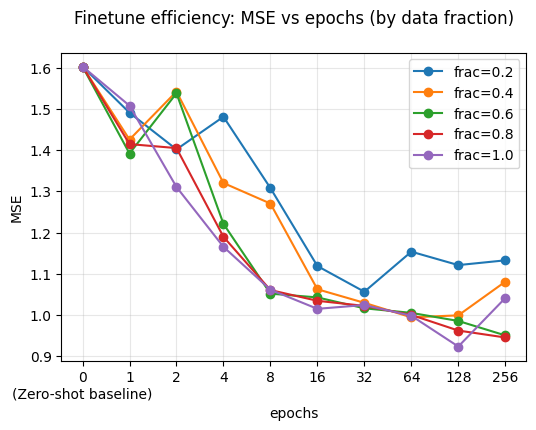

Saved wall-time efficiency plot to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\pretrained_finetune\plots\finetune_adapters_lora_efficiency_wall_time_s_by_frac.png


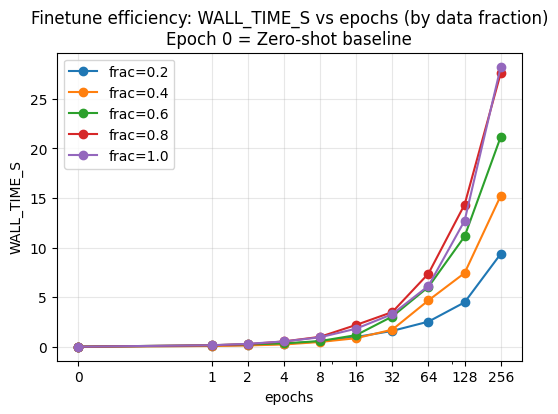

In [44]:
# Run LoRA adapter finetune + unified assessment
LORA_VARIANT = "adapters_lora"
RUN_LORA_ADAPTERS = True
LORA_EPOCH_SWEEP = [0, 1, 2, 4, 8, 16, 32, 64, 128, 256]
LORA_DATA_FRAC_SWEEP = [1.0, 0.8, 0.6, 0.4, 0.2]
LORA_LR = cfg.finetune_lr
LORA_METRIC = "mse"
SHOW_LORA_PLOTS = True
USE_BEST_LORA_CFG = True

_original_lora_cfg = FINETUNE_VARIANTS["adapters_lora"].get("adapter_cfg", {}).copy()
_applied_best_cfg = False
if USE_BEST_LORA_CFG and "lora_best_config" in globals() and lora_best_config is not None and not lora_best_config.empty:
    best_row = lora_best_config.iloc[0]
    best_cfg = {
        "rank": int(best_row["lora_rank"]),
        "alpha": float(best_row["lora_alpha"]),
        "dropout": float(best_row["lora_dropout"]),
        "train_bias": False,
        "train_base": False,
    }
    FINETUNE_VARIANTS["adapters_lora"]["adapter_cfg"] = best_cfg
    _applied_best_cfg = True
    print(f"Using best LoRA config from sweep: {best_cfg}")

if RUN_LORA_ADAPTERS:
    lora_runs = []
    lora_metrics = None

    for data_frac in LORA_DATA_FRAC_SWEEP:
        runs = run_finetune_variant_sweep(
            LORA_VARIANT,
            SPLITS,
            cfg,
            paths,
            PRETRAIN_RUN,
            data_frac=data_frac,
            epoch_sweep=LORA_EPOCH_SWEEP,
            lr=LORA_LR,
        )
        if runs:
            lora_runs.extend(runs)

    if lora_runs:
        eval_out = evaluate_finetune_run(lora_runs[-1], SPLITS, cfg, paths)
        if eval_out is not None:
            lora_metrics, finetune_path = eval_out
            print(f"Finetune metrics saved to {finetune_path}")

        runs_df = summarize_finetune_runs(lora_runs)
        plot_finetune_efficiency_by_frac(
            runs_df,
            metric=LORA_METRIC,
            out_dir=paths.plots,
            show=SHOW_LORA_PLOTS,
            prefix=f"finetune_{LORA_VARIANT}"
        )
        plot_finetune_wall_time_by_frac(
            runs_df,
            out_dir=paths.plots,
            show=SHOW_LORA_PLOTS,
            prefix=f"finetune_{LORA_VARIANT}"
        )

        if lora_metrics is not None:
            aggregate_results(globals().get("zero_shot_df"), lora_metrics, paths)
    else:
        print("No LoRA adapter runs completed.")
else:
    print("Skipped LoRA adapter run.")

if _applied_best_cfg:
    FINETUNE_VARIANTS["adapters_lora"]["adapter_cfg"] = _original_lora_cfg

### DoRA adapters


In [45]:
import importlib
import src.models.adapters as adapters
importlib.reload(adapters)

# DoRA hyperparameter sweep (PEFT)
force_rerun_dora = True
dora_sweep_path = paths.results / "dora_param_sweep.csv"

DORA_SWEEP_DATA_FRAC = 1.0
DORA_SWEEP_EPOCHS = [100]
DORA_SWEEP_VARIANT = "adapters_dora"
DORA_SWEEP_LR = cfg.finetune_lr

if dora_sweep_path.exists() and not force_rerun_dora:
    dora_sweep_df = pd.read_csv(dora_sweep_path)
else:
    import contextlib
    import io

    original_cfg = FINETUNE_VARIANTS["adapters_dora"].get("adapter_cfg", {}).copy()
    dora_sweep_rows: List[Dict[str, object]] = []

    try:
        for rank in [4, 8, 16]:
            for alpha in [rank, 2 * rank]:
                for dropout in [0.0, 0.05]:
                    adapter_cfg = {
                        "rank": rank,
                        "alpha": float(alpha),
                        "dropout": float(dropout),
                        "train_bias": False,
                        "train_base": False,
                    }
                    FINETUNE_VARIANTS["adapters_dora"]["adapter_cfg"] = adapter_cfg

                    print(f"DoRA sweep rank={rank} alpha={alpha} dropout={dropout} data_frac={DORA_SWEEP_DATA_FRAC}")
                    with contextlib.redirect_stdout(io.StringIO()):
                        runs = run_finetune_variant_sweep(
                            DORA_SWEEP_VARIANT,
                            SPLITS,
                            cfg,
                            paths,
                            PRETRAIN_RUN,
                            data_frac=DORA_SWEEP_DATA_FRAC,
                            epoch_sweep=DORA_SWEEP_EPOCHS,
                            lr=DORA_SWEEP_LR,
                        )
                    if not runs:
                        continue

                    for run in runs:
                        metrics = run.get("test_metrics", {})
                        train_stats = run.get("train_stats", {})
                        param_counts = run.get("param_counts", {})
                        total_params = param_counts.get("total_params")
                        trainable_params = param_counts.get("trainable_params")
                        dora_sweep_rows.append(
                            {
                                "adapter": "dora",
                                "dora_rank": rank,
                                "dora_alpha": alpha,
                                "dora_dropout": dropout,
                                "train_base": False,
                                "train_bias": False,
                                "epochs": run.get("epochs"),
                                "data_frac": run.get("data_frac"),
                                "lr": run.get("lr"),
                                "wall_time_s": run.get("wall_time_s"),
                                "steps": train_stats.get("steps"),
                                "steps_per_sec": train_stats.get("steps_per_sec"),
                                "peak_mem_bytes": train_stats.get("peak_mem_bytes"),
                                "total_params": total_params,
                                "trainable_params": trainable_params,
                                "trainable_ratio": (trainable_params / total_params) if total_params else None,
                                "trainable_pct": (trainable_params / total_params) if total_params else None,
                                "test_mse": metrics.get("mse"),
                                "test_mae": metrics.get("mae"),
                                "test_rmse": metrics.get("rmse"),
                            }
                        )
    finally:
        FINETUNE_VARIANTS["adapters_dora"]["adapter_cfg"] = original_cfg

    dora_sweep_df = pd.DataFrame(dora_sweep_rows)
    dora_sweep_df.to_csv(dora_sweep_path, index=False)

if dora_sweep_df is not None and not dora_sweep_df.empty:
    dora_best_config = dora_sweep_df.sort_values("test_mse").head(1).reset_index(drop=True)
    print("Best DoRA config by test_mse:")
    print(
        dora_best_config[
            [
                "dora_rank",
                "dora_alpha",
                "dora_dropout",
                "test_mse",
                "test_mae",
                "test_rmse",
                "wall_time_s",
            ]
        ]
    )
else:
    dora_best_config = pd.DataFrame()

DoRA sweep rank=4 alpha=4 dropout=0.0 data_frac=1.0
DoRA sweep rank=4 alpha=4 dropout=0.05 data_frac=1.0
DoRA sweep rank=4 alpha=8 dropout=0.0 data_frac=1.0
DoRA sweep rank=4 alpha=8 dropout=0.05 data_frac=1.0
DoRA sweep rank=8 alpha=8 dropout=0.0 data_frac=1.0
DoRA sweep rank=8 alpha=8 dropout=0.05 data_frac=1.0
DoRA sweep rank=8 alpha=16 dropout=0.0 data_frac=1.0
DoRA sweep rank=8 alpha=16 dropout=0.05 data_frac=1.0
DoRA sweep rank=16 alpha=16 dropout=0.0 data_frac=1.0
DoRA sweep rank=16 alpha=16 dropout=0.05 data_frac=1.0
DoRA sweep rank=16 alpha=32 dropout=0.0 data_frac=1.0
DoRA sweep rank=16 alpha=32 dropout=0.05 data_frac=1.0
Best DoRA config by test_mse:
   dora_rank  dora_alpha  dora_dropout  test_mse  test_mae  test_rmse  \
0          4           8           0.0  0.947739  0.645497   0.973519   

   wall_time_s  
0    10.582301  


Using best DoRA config from sweep: {'rank': 4, 'alpha': 8.0, 'dropout': 0.0, 'train_bias': False, 'train_base': False}
Epoch 001 | train MSE 4.1462 | val MSE 1.1082 | train MAE 1.5867 | val MAE 0.8328
Epoch 010 | train MSE 3.4511 | val MSE 0.8298 | train MAE 1.4610 | val MAE 0.6717
Epoch 020 | train MSE 3.3264 | val MSE 0.8345 | train MAE 1.4366 | val MAE 0.6823
Epoch 030 | train MSE 3.3875 | val MSE 0.8760 | train MAE 1.4656 | val MAE 0.7134
Epoch 040 | train MSE 3.3317 | val MSE 0.7670 | train MAE 1.4699 | val MAE 0.6446
Epoch 050 | train MSE 3.4544 | val MSE 0.8761 | train MAE 1.4758 | val MAE 0.7273
Epoch 060 | train MSE 3.4189 | val MSE 0.7898 | train MAE 1.4679 | val MAE 0.6820
Epoch 070 | train MSE 3.3029 | val MSE 0.8167 | train MAE 1.4461 | val MAE 0.7012
Epoch 080 | train MSE 3.4508 | val MSE 0.7810 | train MAE 1.4888 | val MAE 0.6812
Epoch 090 | train MSE 3.1598 | val MSE 0.7925 | train MAE 1.4269 | val MAE 0.6901
Epoch 100 | train MSE 3.3490 | val MSE 0.7492 | train MAE 1.4

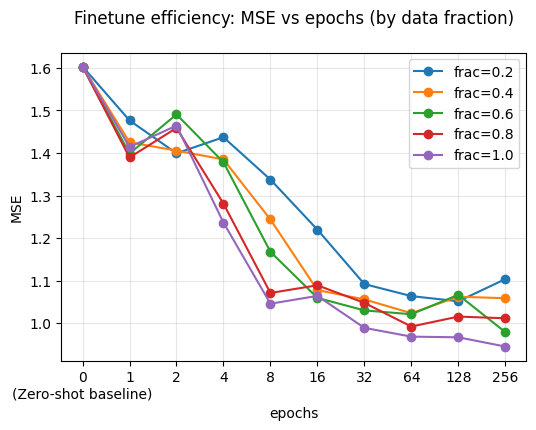

Saved wall-time efficiency plot to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\pretrained_finetune\plots\finetune_adapters_dora_efficiency_wall_time_s_by_frac.png


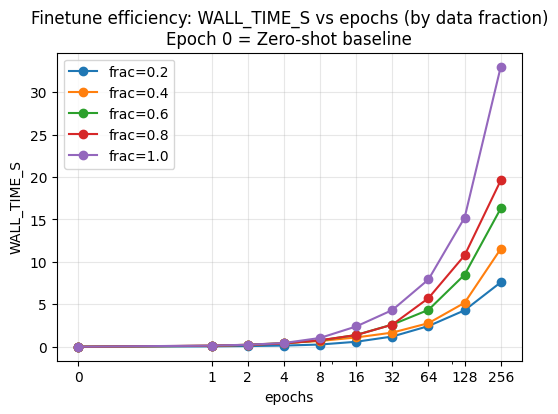

In [46]:
# Run DoRA adapter finetune + unified assessment (uses best sweep config)
DORA_VARIANT = "adapters_dora"
RUN_DORA_ADAPTERS = True
DORA_EPOCH_SWEEP = [0, 1, 2, 4, 8, 16, 32, 64, 128, 256]
DORA_DATA_FRAC_SWEEP = [1.0, 0.8, 0.6, 0.4, 0.2]
DORA_LR = cfg.finetune_lr
DORA_METRIC = "mse"
SHOW_DORA_PLOTS = True
USE_BEST_DORA_CFG = True

_original_dora_cfg = FINETUNE_VARIANTS["adapters_dora"].get("adapter_cfg", {}).copy()
_applied_dora_best = False
if USE_BEST_DORA_CFG and dora_best_config is not None and not dora_best_config.empty:
    best_row = dora_best_config.iloc[0]
    best_cfg = {
        "rank": int(best_row["dora_rank"]),
        "alpha": float(best_row["dora_alpha"]),
        "dropout": float(best_row["dora_dropout"]),
        "train_bias": False,
        "train_base": False,
    }
    FINETUNE_VARIANTS["adapters_dora"]["adapter_cfg"] = best_cfg
    _applied_dora_best = True
    print(f"Using best DoRA config from sweep: {best_cfg}")

if RUN_DORA_ADAPTERS:
    dora_runs = []
    dora_metrics = None

    for data_frac in DORA_DATA_FRAC_SWEEP:
        runs = run_finetune_variant_sweep(
            DORA_VARIANT,
            SPLITS,
            cfg,
            paths,
            PRETRAIN_RUN,
            data_frac=data_frac,
            epoch_sweep=DORA_EPOCH_SWEEP,
            lr=DORA_LR,
        )
        if runs:
            dora_runs.extend(runs)

    if dora_runs:
        eval_out = evaluate_finetune_run(dora_runs[-1], SPLITS, cfg, paths)
        if eval_out is not None:
            dora_metrics, finetune_path = eval_out
            print(f"Finetune metrics saved to {finetune_path}")

        runs_df = summarize_finetune_runs(dora_runs)
        plot_finetune_efficiency_by_frac(
            runs_df,
            metric=DORA_METRIC,
            out_dir=paths.plots,
            show=SHOW_DORA_PLOTS,
            prefix=f"finetune_{DORA_VARIANT}"
        )
        plot_finetune_wall_time_by_frac(
            runs_df,
            out_dir=paths.plots,
            show=SHOW_DORA_PLOTS,
            prefix=f"finetune_{DORA_VARIANT}"
        )

        if dora_metrics is not None:
            aggregate_results(globals().get("zero_shot_df"), dora_metrics, paths)
    else:
        print("No DoRA adapter runs completed.")
else:
    print("Skipped DoRA adapter run.")

if _applied_dora_best:
    FINETUNE_VARIANTS["adapters_dora"]["adapter_cfg"] = _original_dora_cfg

In [47]:
# Optional: rerun top-K configs with multiple seeds and aggregate mean/std
RUN_MULTI_SEED = True
TOP_K = 3
MULTI_SEEDS = [0, 1, 2]

if RUN_MULTI_SEED:
    def _read_results_csv(path: Path) -> pd.DataFrame:
        if not path.exists():
            return pd.DataFrame()
        try:
            return pd.read_csv(path)
        except pd.errors.ParserError:
            import csv

            with path.open("r", encoding="utf-8", newline="") as f:
                reader = csv.reader(f)
                header = next(reader)
            n_cols = len(header)

            def _fix_bad_line(bad_line: List[str]) -> List[str]:
                if len(bad_line) > n_cols:
                    return bad_line[:n_cols]
                if len(bad_line) < n_cols:
                    return bad_line + [""] * (n_cols - len(bad_line))
                return bad_line

            try:
                return pd.read_csv(path, engine="python", on_bad_lines=_fix_bad_line)
            except Exception:
                return pd.read_csv(path, engine="python", on_bad_lines="skip")

    base_results = _read_results_csv(TEST_METRICS_PATH)

    if base_results.empty:
        print("No test metrics found; run a finetune sweep first.")
    else:
        topk = (
            base_results.dropna(subset=["method", "data_frac", "epochs", "lr"])
            .sort_values("mse")
            .head(TOP_K)
        )
        print("Top-K configs to rerun:")
        print(topk[["method", "data_frac", "epochs", "lr", "mse"]])

        rerun_rows = []
        original_seed = cfg.seed
        try:
            for _, row in topk.iterrows():
                method = row["method"]
                data_frac = float(row["data_frac"])
                epochs = int(row["epochs"])
                lr = float(row["lr"])
                for seed in MULTI_SEEDS:
                    cfg.seed = seed
                    set_deterministic_seed(seed)
                    run = run_finetune_variant(
                        method,
                        SPLITS,
                        cfg,
                        paths,
                        PRETRAIN_RUN,
                        data_frac=data_frac,
                        epochs=epochs,
                        lr=lr,
                    )
                    if run is None:
                        continue
                    rerun_rows.append(
                        {
                            "method": method,
                            "data_frac": data_frac,
                            "epochs": epochs,
                            "lr": lr,
                            "seed": seed,
                            "mse": run.get("test_metrics", {}).get("mse"),
                            "trainable_params": run.get("param_counts", {}).get("trainable_params"),
                            "trainable_ratio": run.get("param_counts", {}).get("trainable_ratio"),
                        }
                    )
        finally:
            cfg.seed = original_seed
            set_deterministic_seed(cfg.seed)

        rerun_df = pd.DataFrame(rerun_rows)
        summary = aggregate_seed_metrics(rerun_df, metric_col="mse")
        print("Multi-seed summary (mean/std):")
        print(summary)
else:
    print("Skipped multi-seed reruns.")


Top-K configs to rerun:
               method  data_frac  epochs      lr       mse
108  gradual_unfreeze        1.0     128  0.0005  0.902900
58      full_finetune        1.0     128  0.0005  0.905494
109  gradual_unfreeze        1.0     256  0.0005  0.914802
Epoch 001 | train MSE 3.9158 | val MSE 1.1272 | train MAE 1.5661 | val MAE 0.8374
Epoch 010 | train MSE 3.9928 | val MSE 1.2040 | train MAE 1.5936 | val MAE 0.8893
Epoch 020 | train MSE 3.5649 | val MSE 1.1042 | train MAE 1.4847 | val MAE 0.8423
Epoch 030 | train MSE 3.4225 | val MSE 0.8154 | train MAE 1.4577 | val MAE 0.6971
Epoch 040 | train MSE 3.3697 | val MSE 0.9401 | train MAE 1.4670 | val MAE 0.7775
Epoch 050 | train MSE 3.4441 | val MSE 0.7883 | train MAE 1.4658 | val MAE 0.6863
Epoch 060 | train MSE 3.1961 | val MSE 0.7830 | train MAE 1.4331 | val MAE 0.6885
Epoch 070 | train MSE 2.9824 | val MSE 0.7732 | train MAE 1.3717 | val MAE 0.6591
Epoch 080 | train MSE 3.1937 | val MSE 0.7070 | train MAE 1.4222 | val MAE 0.6238
Ep

In [48]:
# Results Summary
print("Results Summary")


def _read_results_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    try:
        return pd.read_csv(path)
    except pd.errors.ParserError:
        import csv

        with path.open("r", encoding="utf-8", newline="") as f:
            reader = csv.reader(f)
            header = next(reader)
        n_cols = len(header)

        def _fix_bad_line(bad_line: List[str]) -> List[str]:
            if len(bad_line) > n_cols:
                return bad_line[:n_cols]
            if len(bad_line) < n_cols:
                return bad_line + [""] * (n_cols - len(bad_line))
            return bad_line

        try:
            return pd.read_csv(path, engine="python", on_bad_lines=_fix_bad_line)
        except Exception:
            return pd.read_csv(path, engine="python", on_bad_lines="skip")


results_df = _read_results_csv(TEST_METRICS_PATH)

if results_df is None or results_df.empty:
    print("No finetune test metrics found yet.")
else:
    results_df = results_df.rename(columns={"data_frac": "data_fraction"})
    has_multi_seed = "seed" in results_df.columns and results_df["seed"].nunique() > 1

    if has_multi_seed:
        grouped = aggregate_seed_metrics(
            results_df,
            metric_col="mse",
            group_cols=["method", "data_fraction", "epochs", "lr", "trainable_params", "trainable_ratio"],
        )
        summary_df = grouped.rename(columns={"mse_mean": "MSE", "mse_std": "MSE_std"})
    else:
        summary_df = results_df.copy()
        summary_df["MSE"] = summary_df["mse"]

    display_cols = [
        "method",
        "data_fraction",
        "epochs",
        "MSE",
        "trainable_params",
        "trainable_ratio",
    ]
    display_cols = [col for col in display_cols if col in summary_df.columns]

    summary_sorted = summary_df.sort_values("MSE").reset_index(drop=True)
    print("\nNote: epoch=0 corresponds to the zero-shot baseline.")
    print("\nTable sorted by MSE:")
    print(summary_sorted[display_cols])

    param_summary = summarize_param_efficiency(summary_df)
    if param_summary is not None and not param_summary.empty:
        print("\nParameter-efficiency by method:")
        print(param_summary[[col for col in param_summary.columns if col != "total_params"]])

    best_by_frac = summary_sorted.groupby("data_fraction", dropna=False).first().reset_index()
    print("\nBest method per data fraction:")
    print(best_by_frac[[col for col in display_cols if col in best_by_frac.columns]])

    zero_shot_rows = summary_sorted[summary_sorted["epochs"] == 0]
    print("\nZero-shot baseline rows (epoch=0):")
    if zero_shot_rows.empty:
        print("(none found)")
    else:
        print(zero_shot_rows[display_cols])

    if has_multi_seed and "MSE_std" in summary_df.columns:
        extra_cols = ["method", "data_fraction", "epochs", "MSE", "MSE_std", "n_seeds"]
        extra_cols = [col for col in extra_cols if col in summary_df.columns]
        print("\nMulti-seed mean/std detail:")
        print(summary_sorted[extra_cols])


Results Summary

Note: epoch=0 corresponds to the zero-shot baseline.

Table sorted by MSE:
               method  data_fraction  epochs       MSE  trainable_params  \
0       full_finetune            1.0     128  0.917094            179201   
1       full_finetune            1.0     256  0.919836            179201   
2       adapters_lora            1.0     128  0.923103             30928   
3    gradual_unfreeze            0.6     128  0.923581            179201   
4    gradual_unfreeze            1.0     128  0.924859            179201   
..                ...            ...     ...       ...               ...   
251         head_only            0.2       0  1.603110            179201   
252         head_only            1.0       0  1.603110            179201   
253         head_only            0.6       0  1.603110            179201   
254     full_finetune            0.6       2  1.782020            179201   
255     full_finetune            0.2       1  2.057455            179201

## Budget-Oriented Evaluation
Publication-style comparisons under fixed compute budgets.


Budget columns present: {'seen_samples': True, 'trainable_params': True, 'train_samples_used': True, 'steps': True}


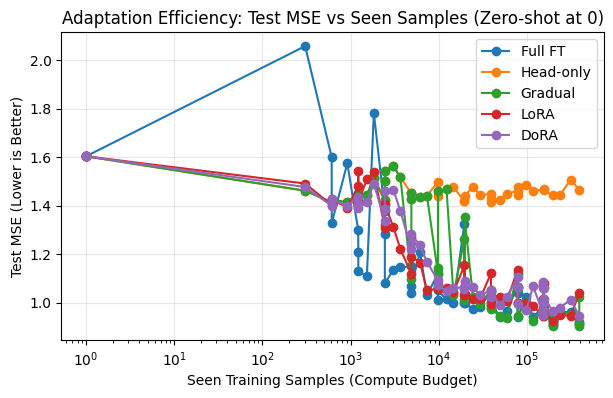

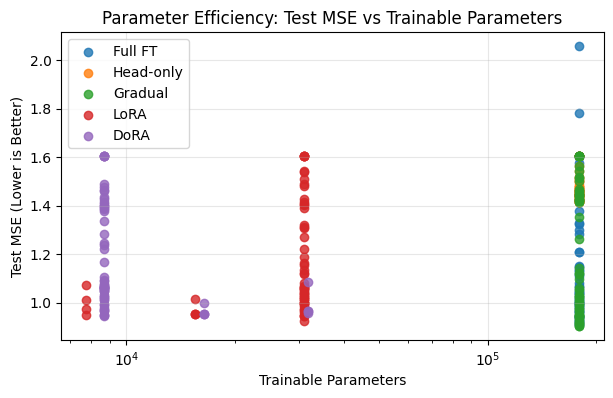


Budget tier ~50,000 seen samples:
      method  seen_samples  test_mse  trainable_params  trainable_ratio
0    Full FT         48928  0.940648            179201         1.000000
2    Gradual         48928  0.946629            179201         1.000000
4       DoRA         48928  0.989033              8693         0.046265
3       LoRA         48928  1.023856             30928         0.147186
1  Head-only         48928  1.423582            179201         1.000000

Budget tier ~100,000 seen samples:
      method  seen_samples  test_mse  trainable_params  trainable_ratio
4       DoRA         97856  0.968380              8693         0.046265
3       LoRA         97856  0.997813             30928         0.147186
2    Gradual         97856  1.001241            179201         1.000000
0    Full FT         97856  1.023873            179201         1.000000
1  Head-only         97856  1.484677            179201         1.000000

Budget tier ~200,000 seen samples:
      method  seen_samples  t

In [50]:
import matplotlib.pyplot as plt

method_order = ["full_finetune", "head_only", "gradual_unfreeze", "adapters_lora", "adapters_dora"]
summary_dir = paths.results / "budget_summary"
summary_dir.mkdir(parents=True, exist_ok=True)
method_labels = {
    "full_finetune": "Full FT",
    "head_only": "Head-only",
    "gradual_unfreeze": "Gradual",
    "adapters_lora": "LoRA",
    "adapters_dora": "DoRA",
}
method_colors = {
    "full_finetune": "#1f77b4",
    "head_only": "#ff7f0e",
    "gradual_unfreeze": "#2ca02c",
    "adapters_lora": "#d62728",
    "adapters_dora": "#9467bd",
}

budget_df = _read_results_csv(TEST_METRICS_PATH)
runs_index_df = _read_results_csv(RUNS_INDEX_PATH)

if budget_df is None or budget_df.empty:
    print("No finetune test metrics found; run a sweep first.")
else:
    if "run_id" in budget_df.columns and "run_id" in runs_index_df.columns:
        merged = budget_df.merge(runs_index_df, on="run_id", how="left", suffixes=("", "_run"))
    else:
        merged = budget_df.copy()

    merged = merged.rename(columns={"data_frac": "data_fraction"})
    if "test_mse" not in merged.columns and "mse" in merged.columns:
        merged["test_mse"] = merged["mse"]

    full_train_size = len(load_post2005_split_dfs()["train"])
    merged["data_fraction"] = pd.to_numeric(merged.get("data_fraction"), errors="coerce")
    merged["epochs"] = pd.to_numeric(merged.get("epochs"), errors="coerce")

    if "train_samples_used" not in merged.columns:
        merged["train_samples_used"] = (merged["data_fraction"] * full_train_size).fillna(0).astype(int)

    if "seen_samples" not in merged.columns:
        merged["seen_samples"] = (merged["train_samples_used"] * merged["epochs"]).fillna(0).astype(int)

    if "steps" not in merged.columns:
        n_train = pd.to_numeric(merged.get("n_train"), errors="coerce")
        batch_size = pd.to_numeric(merged.get("batch_size"), errors="coerce")
        if n_train is not None and batch_size is not None:
            steps_per_epoch = np.ceil(n_train / batch_size)
            merged["steps"] = (merged["epochs"] * steps_per_epoch).fillna(0).astype(int)
        else:
            merged["steps"] = np.nan

    merged = merged[merged["method"].isin(method_order)].copy()
    merged.to_csv(summary_dir / "budget_runs.csv", index=False)
    print("Budget columns present:", {
        "seen_samples": "seen_samples" in merged.columns,
        "trainable_params": "trainable_params" in merged.columns,
        "train_samples_used": "train_samples_used" in merged.columns,
        "steps": "steps" in merged.columns,
    })

    # Adaptation efficiency plot
    fig, ax = plt.subplots(figsize=(7, 4))
    eps = 1.0
    for method in method_order:
        sub = merged[merged["method"] == method].dropna(subset=["seen_samples", "test_mse"])
        if sub.empty:
            continue
        sub = sub.sort_values("seen_samples")
        sub_plot = sub.copy()
        sub_plot["seen_samples_plot"] = sub_plot["seen_samples"].replace(0, eps)
        ax.plot(
            sub_plot["seen_samples_plot"],
            sub_plot["test_mse"],
            marker="o",
            color=method_colors.get(method),
            label=method_labels.get(method, method),
        )

    ax.set_title("Adaptation Efficiency: Test MSE vs Seen Samples (Zero-shot at 0)")
    ax.set_xlabel("Seen Training Samples (Compute Budget)")
    ax.set_ylabel("Test MSE (Lower is Better)")
    ax.set_xscale("log")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.savefig(summary_dir / "adaptation_efficiency_mse_vs_seen_samples.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Parameter efficiency plot
    fig, ax = plt.subplots(figsize=(7, 4))
    for method in method_order:
        sub = merged[merged["method"] == method].dropna(subset=["trainable_params", "test_mse"])
        if sub.empty:
            continue
        ax.scatter(
            sub["trainable_params"],
            sub["test_mse"],
            color=method_colors.get(method),
            label=method_labels.get(method, method),
            alpha=0.8,
        )

    ax.set_title("Parameter Efficiency: Test MSE vs Trainable Parameters")
    ax.set_xlabel("Trainable Parameters")
    ax.set_ylabel("Test MSE (Lower is Better)")
    ax.set_xscale("log")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.savefig(summary_dir / "parameter_efficiency_mse_vs_trainable_params.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Budget table
    budget_tiers = [50_000, 100_000, 200_000, 500_000]
    for budget in budget_tiers:
        rows = []
        for method in method_order:
            sub = merged[merged["method"] == method].dropna(subset=["seen_samples", "test_mse"])
            if sub.empty:
                continue
            idx = (sub["seen_samples"] - budget).abs().idxmin()
            row = sub.loc[idx]
            rows.append(
                {
                    "method": method_labels.get(method, method),
                    "seen_samples": int(row["seen_samples"]),
                    "test_mse": float(row["test_mse"]),
                    "trainable_params": int(row["trainable_params"]) if not pd.isna(row.get("trainable_params")) else None,
                    "trainable_ratio": float(row["trainable_ratio"]) if not pd.isna(row.get("trainable_ratio")) else None,
                }
            )
        tier_df = pd.DataFrame(rows).sort_values("test_mse")
        tier_df.to_csv(summary_dir / f"budget_tier_{budget}.csv", index=False)
        print(f"\nBudget tier ~{budget:,} seen samples:")
        print(tier_df)

    # Time-to-target analysis
    full_best = merged[merged["method"] == "full_finetune"]["test_mse"].min()
    if pd.isna(full_best):
        print("\nNo full_finetune results found for time-to-target analysis.")
    else:
        target_mse = 1.05 * full_best
        target_rows = []
        for method in method_order:
            sub = merged[(merged["method"] == method) & (merged["test_mse"] <= target_mse)]
            if sub.empty:
                min_seen = None
            else:
                min_seen = int(sub["seen_samples"].min())
            target_rows.append(
                {
                    "method": method_labels.get(method, method),
                    "min_seen_samples_to_target": min_seen,
                }
            )
        target_df = pd.DataFrame(target_rows)
        target_df.to_csv(summary_dir / "time_to_target.csv", index=False)
        print(f"\nTarget MSE = {target_mse:.4f} (1.05 × best Full FT)")
        print(target_df)
